# Important note about feature matrix update
During the development of this project, a minor logical issue was identified in the SQL feature‑generation pipeline. After fixing it, the resulting feature values changed slightly. Importantly:

- the distribution of features remained the same,

- the percentage of zero‑values remained almost identical,

- the magnitude of changes was too small to affect model selection or chosen hyperparameters.

Because of this, the workflow in this notebook is organized as follows:

- EDA, MI scores and feature analysis are performed on the fixed feature matrix.

- Model selection was originally done on the previous feature matrix, because the update did not meaningfully change feature behavior.

- The final model is trained using the fixed train set with the selected hyperparameters.

- Confusion matrices, SHAP explanations and evaluation are also computed on the fixed train set.

This approach is valid because the correction in the SQL pipeline did not introduce any structural changes to the data and did not affect the conclusions of model selection

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go


from google.colab import drive
from google.colab import files


from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    average_precision_score,
    precision_recall_curve,
)

from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

import shap

import joblib

In [ ]:
import warnings
warnings.filterwarnings("ignore")


In [ ]:
drive.mount('/content/drive')


Mounted at /content/drive


There is an option to load parquet feature matrix and target matrix from *data.processed* folder in my repository and test the whole pipeline. You may expirience sligtly different results with model selection part due to the issue with feature matrix discussed at the beginning of the notebook.

In [ ]:
features = files.upload()


Saving feature_matrix.csv to feature_matrix.csv


In [ ]:
target = files.upload()

Saving target.csv to target (1).csv


In [ ]:

filename = list(features.keys())[0]
features = pd.read_parquet(filename)

filename = list(target.keys())[0]
target = pd.read_parquet(filename)

'\nfilename = list(target.keys())[0]\ntarget = pd.read_parquet(filename)'

In [ ]:
features.head()


,customer_id,account_age_days,birth_date,gender,country,city,shopping_frequency,unsuccessful_orders_count,succ_orders_count,avg_order_value,min_order_value,avg_items_per_order,total_succ_items_per_customer,return_cancel_orders_values,return_cancel_orders_items,shopping_frequency_90d,unsuccessful_orders_count_90d,succ_orders_count_90d,avg_order_value_90d,min_order_value_90d,avg_items_per_order_90d,total_succ_items_per_customer_90d,return_cancel_orders_values_90d,return_cancel_orders_items_90d,last_suc_order_interval,last_succ_kept_order_total,last_succ_kept_order_items,last_succ_order_items,last_succ_order_total,days_from_last_return,last_return_total,last_returned_items,days_from_last_cancel,last_cancel_items,last_cancel_total,avg_last3_succ_interval,last3_succ_orders_kept_items_total,last3_succ_orders_kept_total,last3_succ_orders_total,last3_succ_orders_items,last3_return_cancel_order_total,last3_kept_total,last3_cancels_returns_items,last3_kept_items,automotive_items,automotive_spent,beauty_items,beauty_spent,books_items,books_spent,electronics_items,electronics_spent,fashion_items,fashion_spent,food_items,food_spent,home_items,home_spent,pets_items,pets_spent,sports_items,sports_spent,toys_items,toys_spent,automotive_items_returned,automotive_returned_total,beauty_items_returned,beauty_returned_total,books_items_returned,books_returned_total,electronics_items_returned,electronics_returned_total,fashion_items_returned,fashion_returned_total,food_items_returned,food_returned_total,home_items_returned,home_returned_total,pets_items_returned,pets_returned_total,sports_items_returned,sports_returned_total,toys_items_returned,toys_returned_total,discounted_items_total,total_180days_sessions,avg_pages_viewed_180,min_pages_viewed_180,mobile_sessions_count_180,desktop_sessions_count_180,sessions_to_succ_orders_180days,sessions_90d,avg_pages_90d,days_from_last_session,last_session_pages_viewed,avg_session_interval
0,2,444,1977-10-26,Male,Poland,Krakow,0.026667,3,7,3900.918571,209.88,5.857143,41.0,4581.87,13.0,0.03125,3,2,1846.545,388.09,8.0,16.0,2408.33,13.0,55.0,3305.00,10.0,10.0,3305.00,30.0,50.29,1.0,200.0,9.0,2195.05,47.5,18.0,4823.31,4823.31,18.0,50.29,3693.09,1.0,16.0,10.0,8829.75,3.0,214.90,5.0,275.40,9.0,14511.02,3.0,551.39,3.0,85.86,5.0,2672.43,3.0,274.44,3.0,1944.09,13.0,1640.24,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1.0,754.73,1.0,50.29,21.0,27,16.074074,1,19.0,8.0,0.481481,14,15.000000,1,2,7.015873
1,3,1355,1952-05-04,Male,Poland,Krakow,0.010934,2,14,2294.637143,141.72,6.214286,87.0,6461.71,22.0,0.00000,0,0,0.000,0.00,0.0,0.0,0.00,0.0,380.0,1697.87,10.0,10.0,1697.87,0.0,0.00,0.0,1194.0,6.0,1108.26,70.0,18.0,4189.09,4543.92,21.0,354.83,4189.09,3.0,18.0,20.0,12198.46,4.0,145.84,1.0,41.71,10.0,9601.10,9.0,1348.26,13.0,813.01,2.0,295.41,9.0,1545.78,9.0,4794.96,10.0,1340.39,5.0,4103.24,0.0,0.0,4.0,109.12,0.0,0.0,0.0,0.0,0.0,0.0,1.0,183.75,0.0,0.0,0.0,0.00,5.0,795.07,55.0,3,13.666667,7,2.0,1.0,1.333333,2,12.500000,1,18,32.756098
2,4,1275,1949-07-24,Female,Poland,Poznan,0.011797,0,14,2282.033571,267.82,5.571429,78.0,0.00,0.0,0.00000,0,1,1107.760,1107.76,4.0,4.0,0.00,0.0,28.0,1107.76,4.0,4.0,1107.76,0.0,0.00,0.0,0.0,0.0,0.00,69.5,11.0,4223.74,4223.74,11.0,0.00,4223.74,0.0,11.0,14.0,12028.74,7.0,850.08,3.0,67.29,12.0,10464.78,3.0,683.82,6.0,333.64,10.0,3357.30,11.0,1388.08,8.0,2839.11,8.0,1043.39,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.00,46.0,58,13.724138,1,35.0,23.0,0.120690,30,14.100000,2,14,3.563025
3,5,48,1955-12-02,Female,Poland,Warsaw,0.000000,0,0,0.000000,0.00,0.000000,0.0,0.00,0.0,0.00000,0,0,0.000,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.00,0.0,1,16.000000,16,1.0,0.0,0.000000,1,16.000000,15,16,0.000000
4,6,374,1953-

In [ ]:
features.shape

(90917, 96)

Most of Nan values were handled in SQL pipeline if they were corresponding to the actual lack of client's orders/activity. They are already replaced with 0. However birth_date naturaly can contain Null value if not given to the database.

In [ ]:
features.isna().sum().sum()

np.int64(0)

Churn target turned out to be very rare, the initial thought was to see if the multiclass XGBoost will handle it just to test the easiest approach

In [ ]:
target['target'].value_counts()

,count
target,
ACTIVE,65036
AT-RISK,25722
CHURNED,159


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, stratify=target['target'], random_state=42)

# EDA


In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
X_train.describe()

,customer_id,account_age_days,shopping_frequency,unsuccessful_orders_count,succ_orders_count,avg_order_value,min_order_value,avg_items_per_order,total_succ_items_per_customer,return_cancel_orders_values,return_cancel_orders_items,shopping_frequency_90d,unsuccessful_orders_count_90d,succ_orders_count_90d,avg_order_value_90d,min_order_value_90d,avg_items_per_order_90d,total_succ_items_per_customer_90d,return_cancel_orders_values_90d,return_cancel_orders_items_90d,last_suc_order_interval,last_succ_kept_order_total,last_succ_kept_order_items,last_succ_order_items,last_succ_order_total,days_from_last_return,last_return_total,last_returned_items,days_from_last_cancel,last_cancel_items,last_cancel_total,avg_last3_succ_interval,last3_succ_orders_kept_items_total,last3_succ_orders_kept_total,last3_succ_orders_total,last3_succ_orders_items,last3_return_cancel_order_total,last3_kept_total,last3_cancels_returns_items,last3_kept_items,automotive_items,automotive_spent,beauty_items,beauty_spent,books_items,books_spent,electronics_items,electronics_spent,fashion_items,fashion_spent,food_items,food_spent,home_items,home_spent,pets_items,pets_spent,sports_items,sports_spent,toys_items,toys_spent,automotive_items_returned,automotive_returned_total,beauty_items_returned,beauty_returned_total,books_items_returned,books_returned_total,electronics_items_returned,electronics_returned_total,fashion_items_returned,fashion_returned_total,food_items_returned,food_returned_total,home_items_returned,home_returned_total,pets_items_returned,pets_returned_total,sports_items_returned,sports_returned_total,toys_items_returned,toys_returned_total,discounted_items_total,total_180days_sessions,avg_pages_viewed_180,min_pages_viewed_180,mobile_sessions_count_180,desktop_sessions_count_180,sessions_to_succ_orders_180days,sessions_90d,avg_pages_90d,days_from_last_session,last_session_pages_viewed,avg_session_interval
count,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.00000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.00000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000,72733.000000
mean,50051.368705,914.901503,0.013794,1.598820,11.838973,1823.876639,348.766298,5.190106,68.538504,4241.158930,12.112026,0.012086,0.113470,1.28452,1526.961235,1110.107053,4.335416,7.489324,431.423735,1.219983,173.418242,1938.460743,5.508215,5.696273,2003.026898,212.733793,286.611488,0.817951,641.665668,3.668981,1286.170147,84.700954,15.472977,5442.040549,5658.616888,16.104079,814.424584,4885.795139,2.324309,13.888771,7.707849,5780.904226,7.563183,966.141531,7.804298,268.274533,7.540745,9575.526228,7.504407,1567.518623,7.418435,374.190830,7.478160,2270.621194,8.011302,1213.894819,7.310162,3348.886353,7.689288,1343.651039,0.435359,325.689754,0.434122,55.302751,0.452339,15.537863,0.439704,551.630409,0.436473,90.597173,0.428980,21.551667,0.436184,132.623681,0.462184,69.92337,0.425611,194.669840,0.439168,76.264577,40.211445,22.567693,15.346555,3.015798,11.287270,11.280423,0.683231,1

Features' histograms

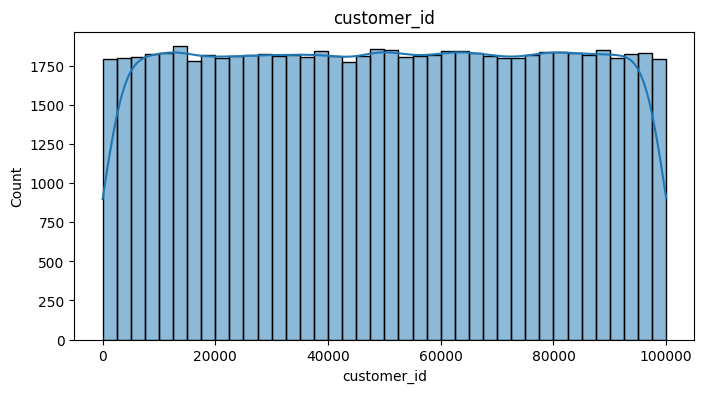

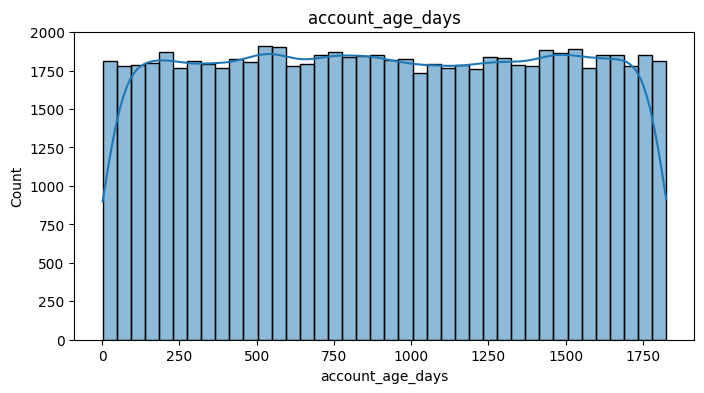

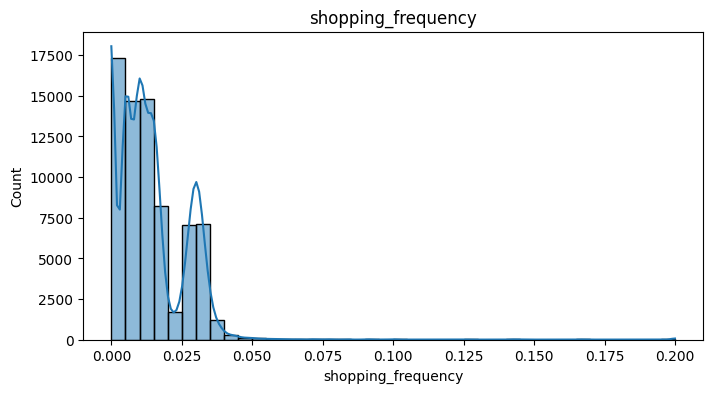

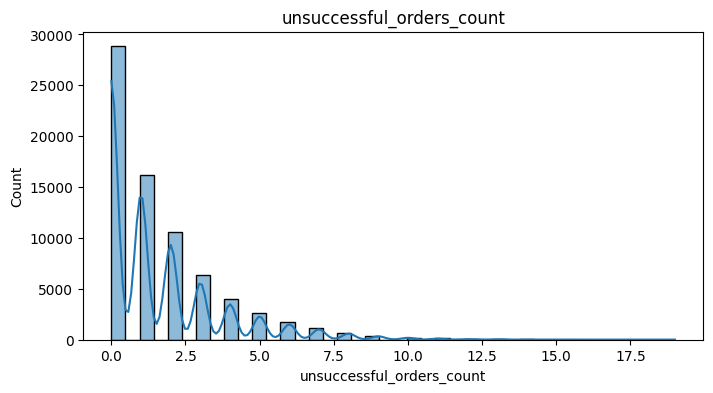

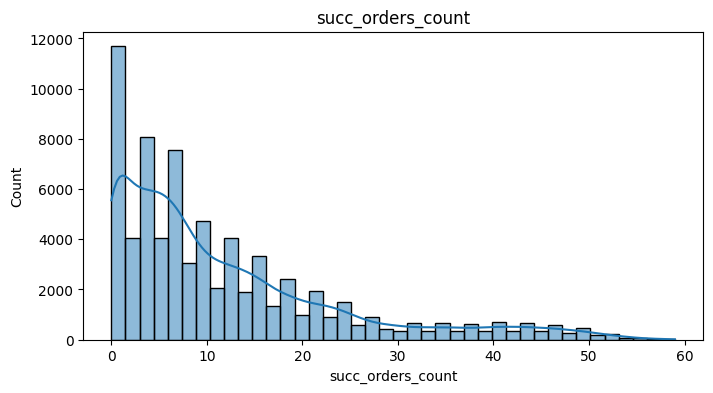

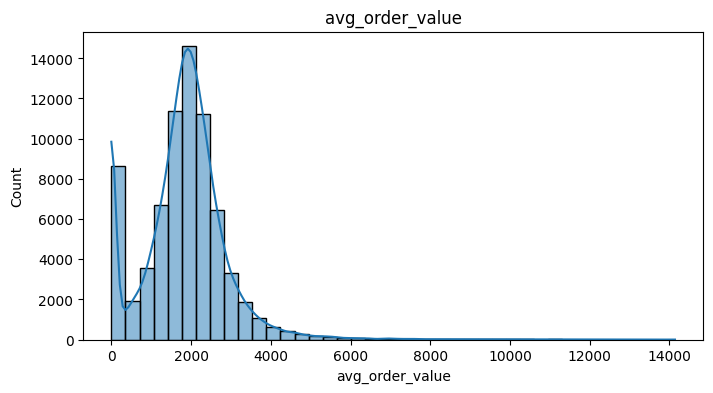

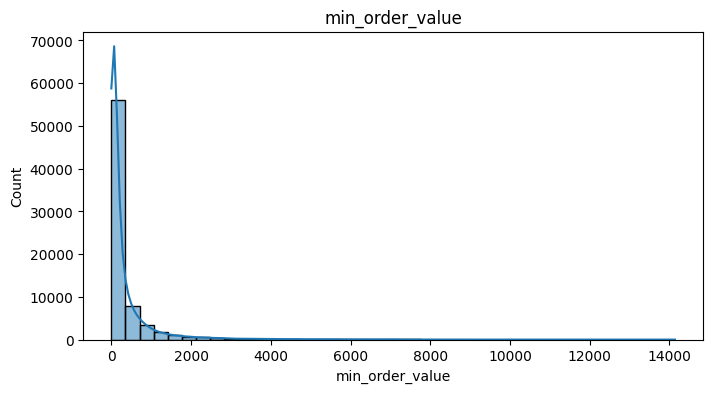

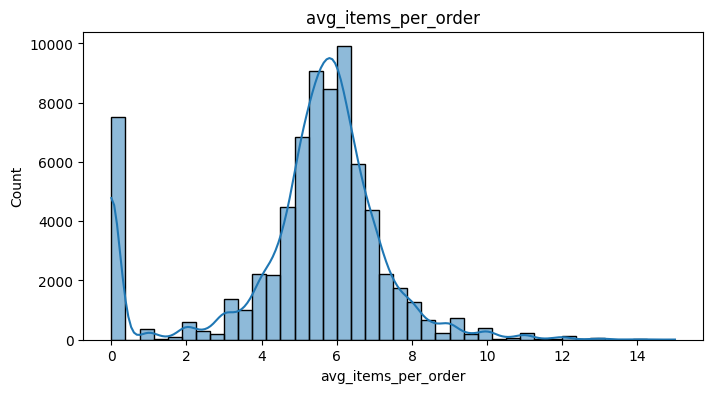

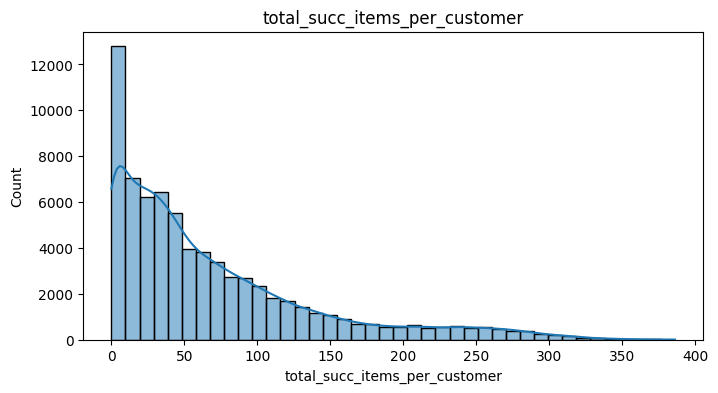

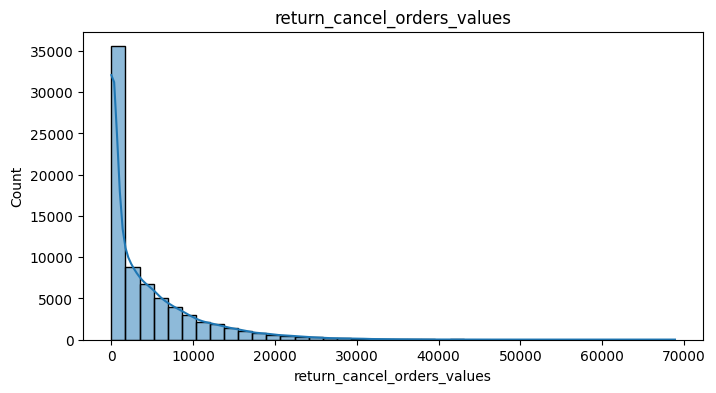

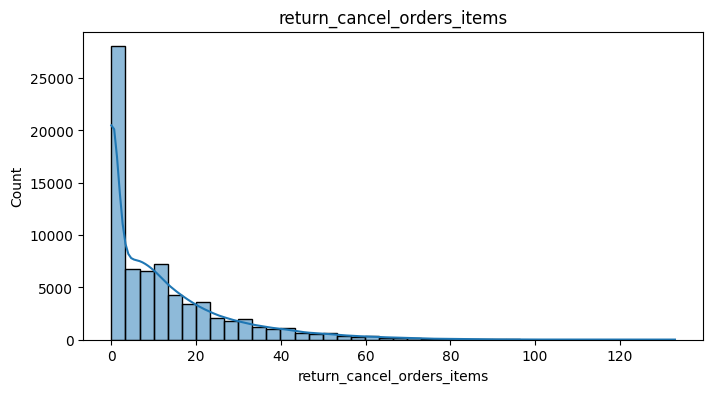

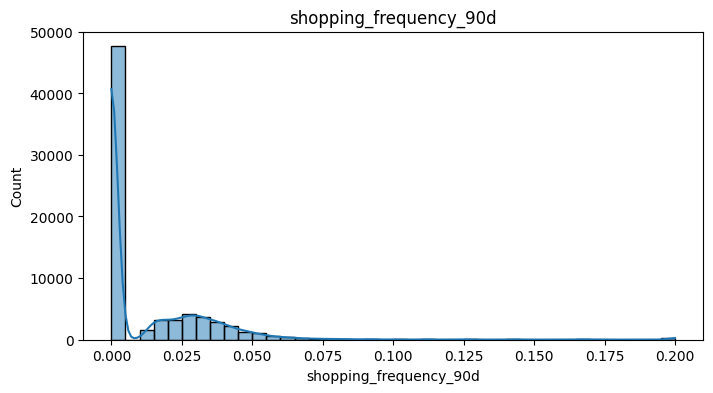

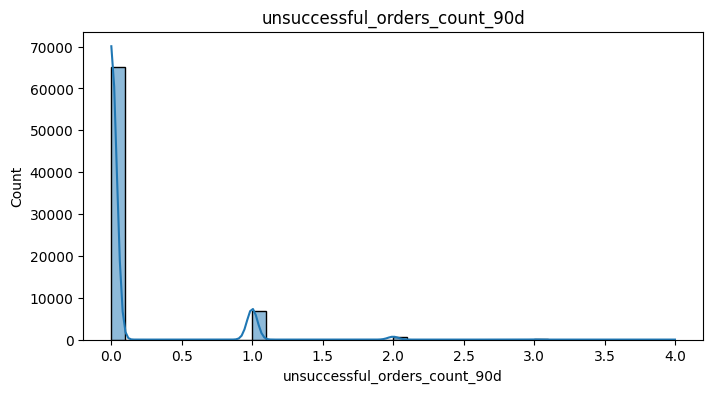

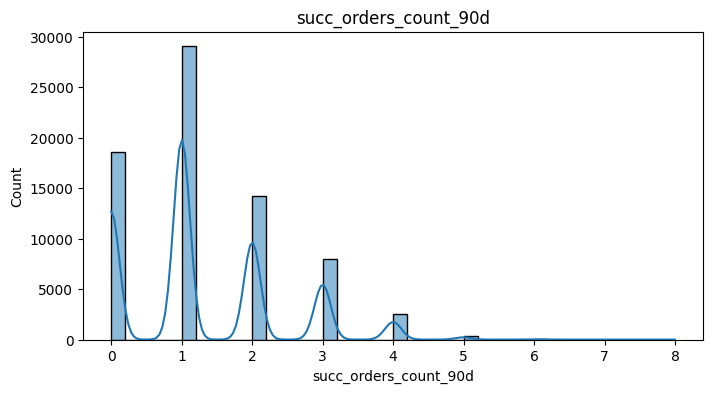

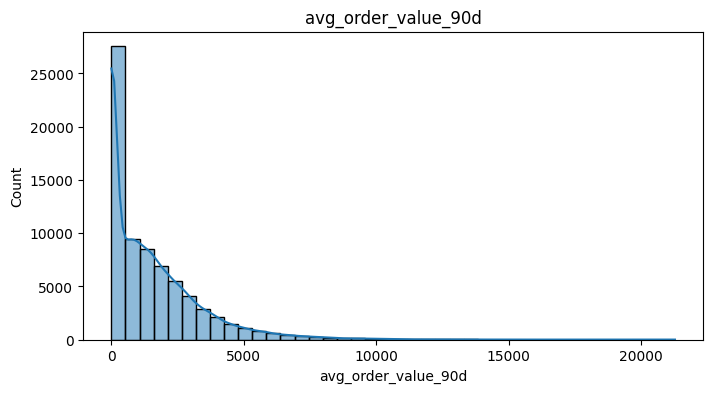

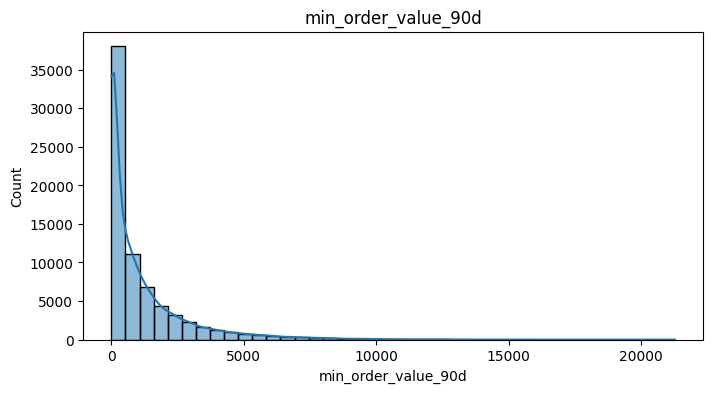

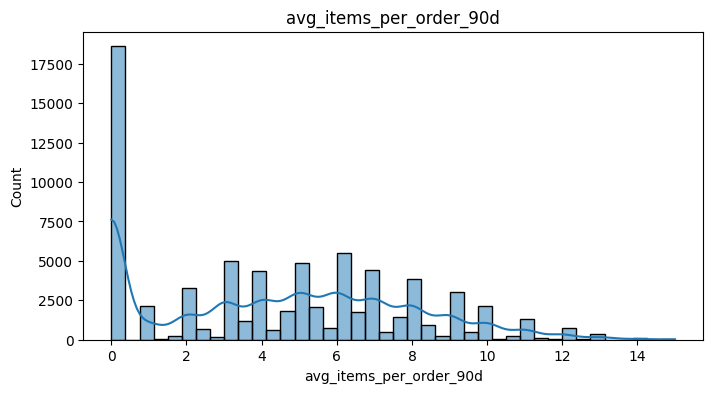

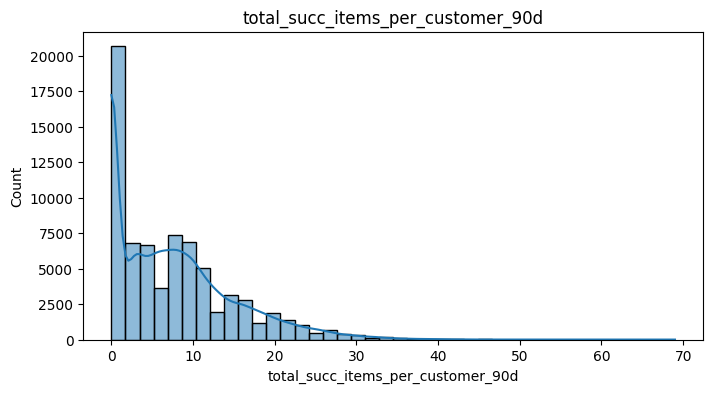

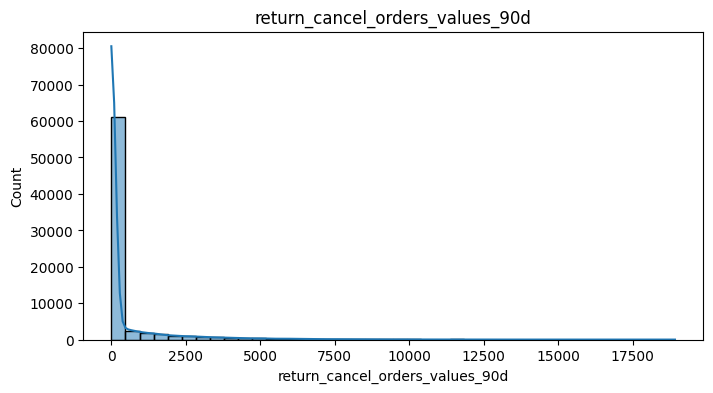

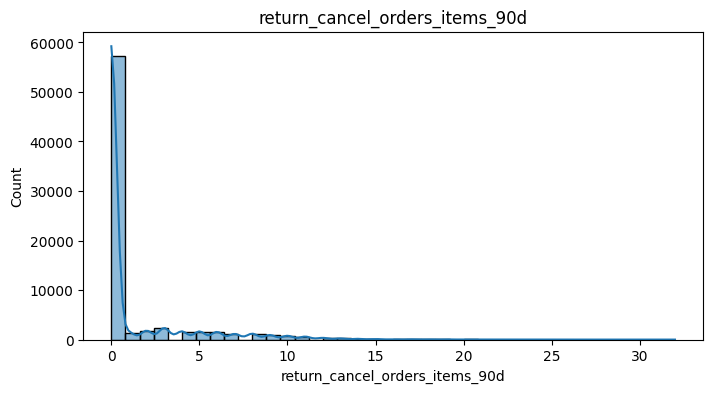

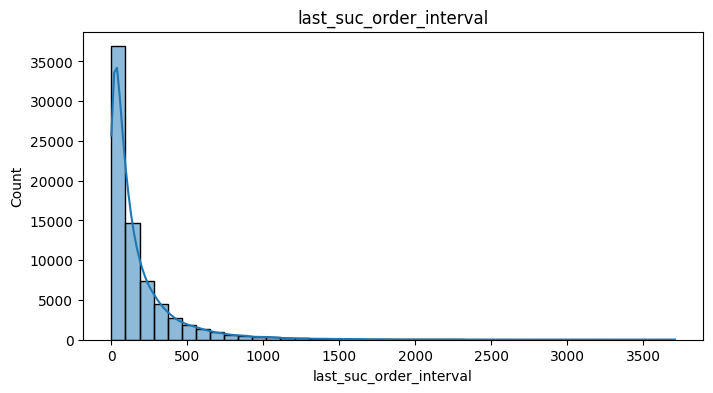

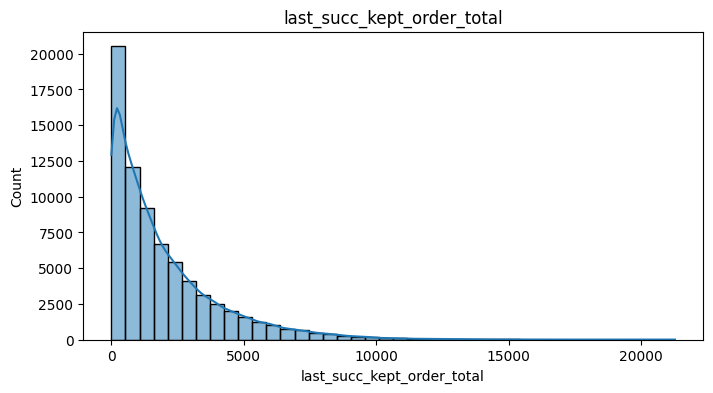

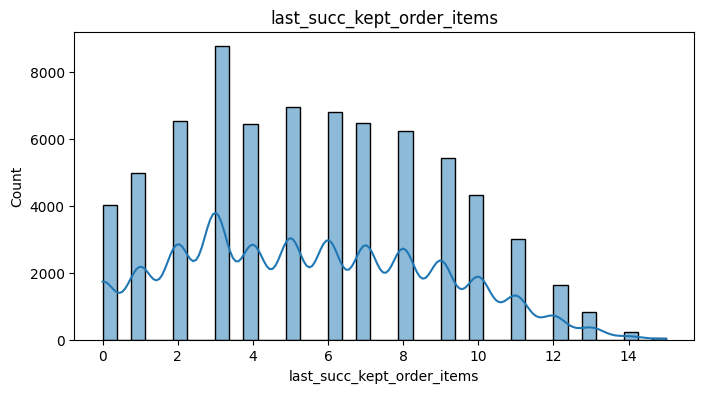

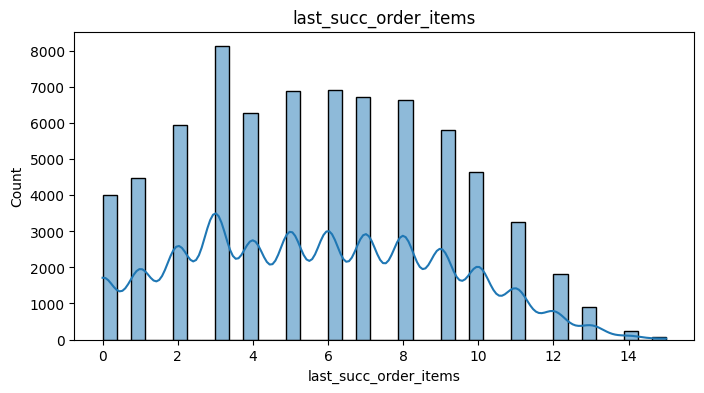

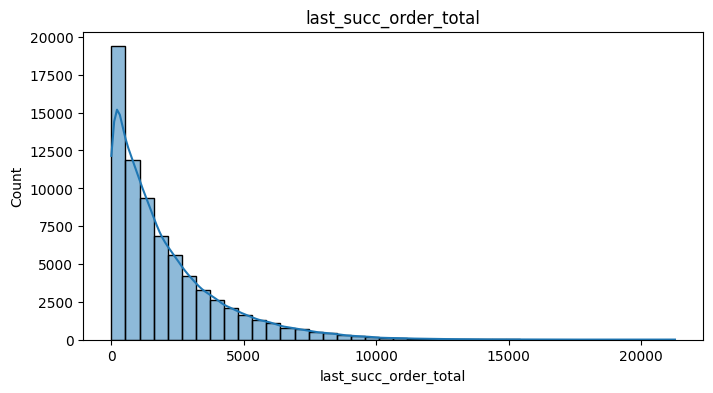

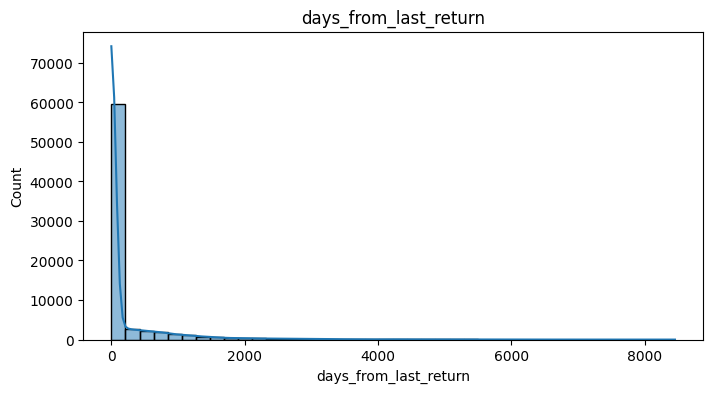

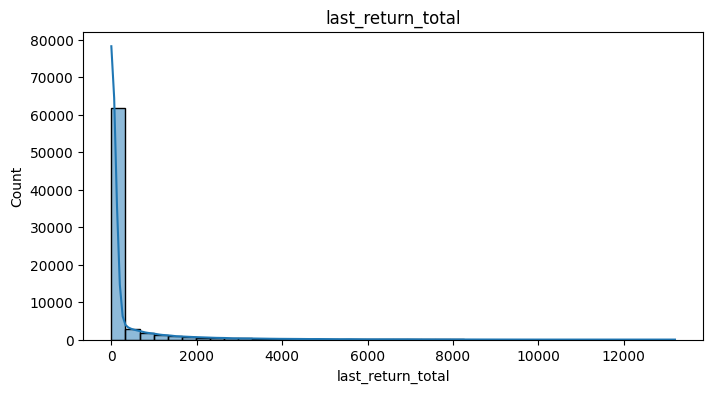

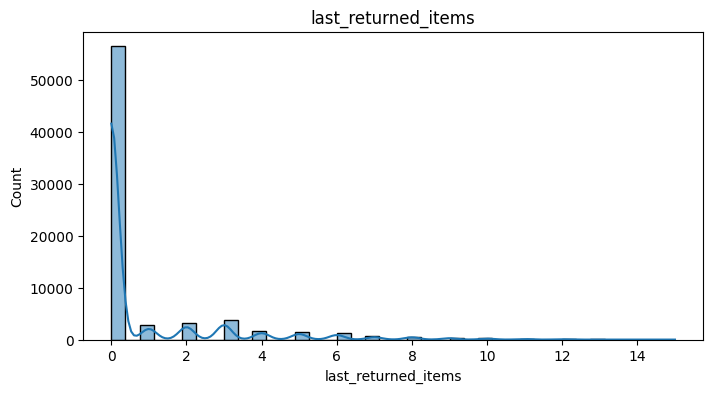

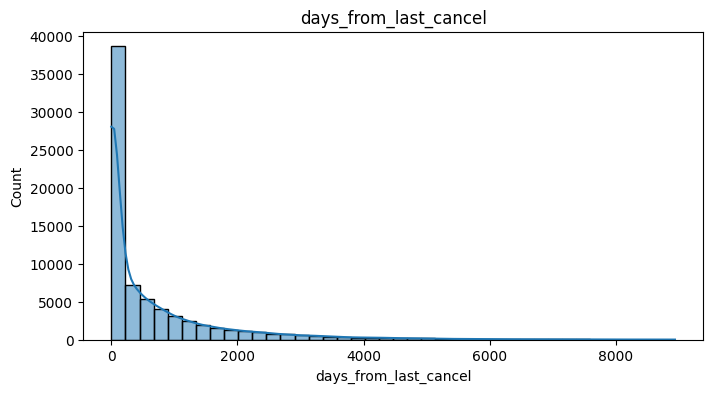

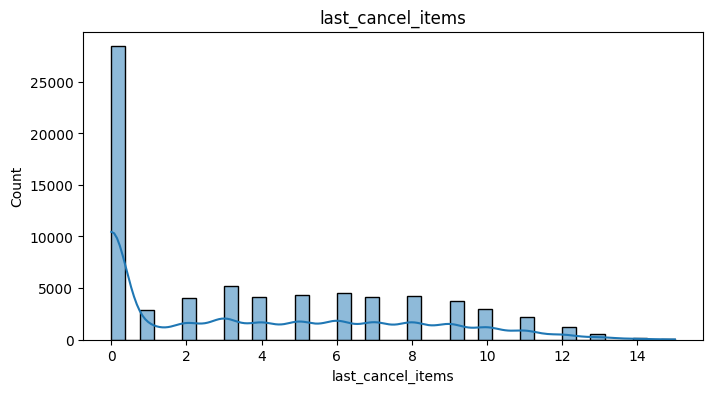

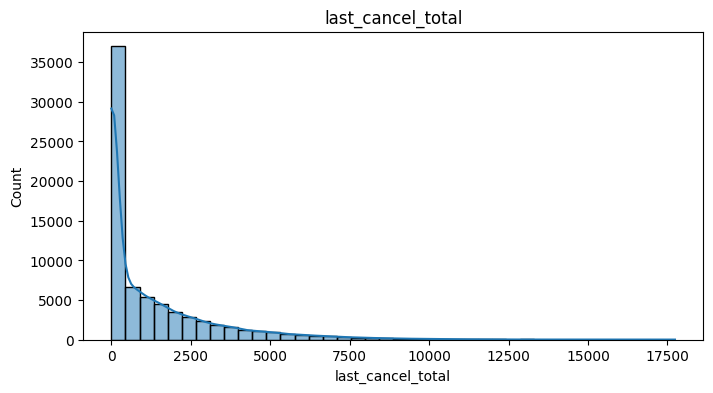

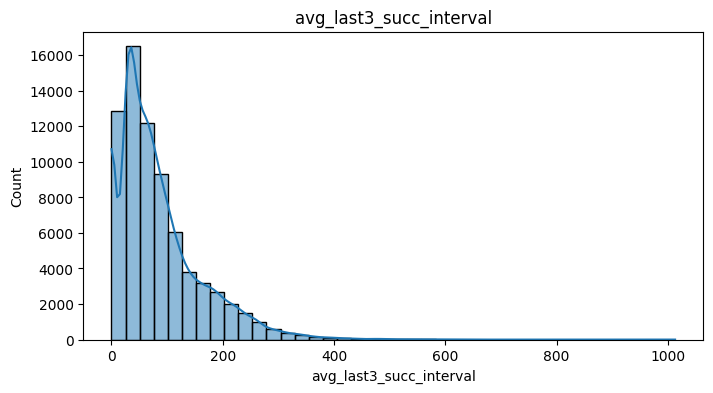

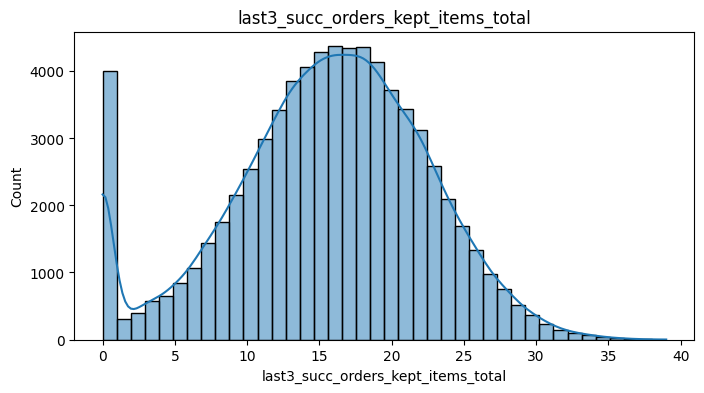

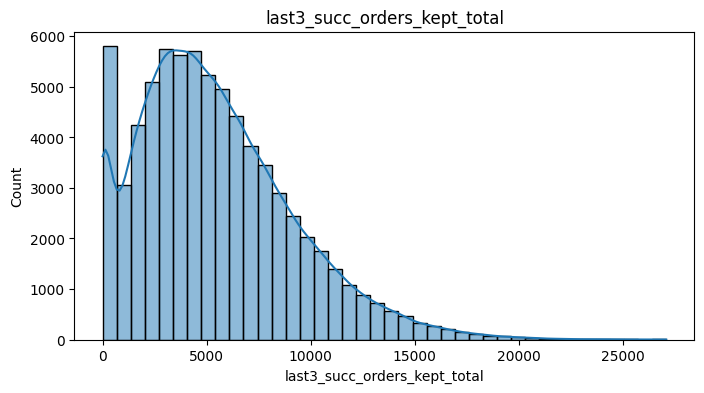

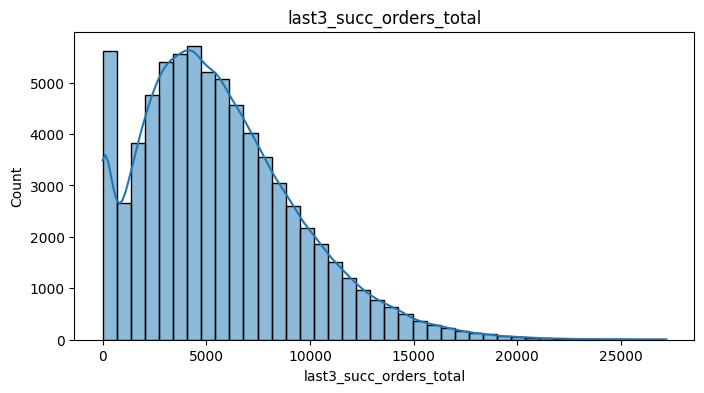

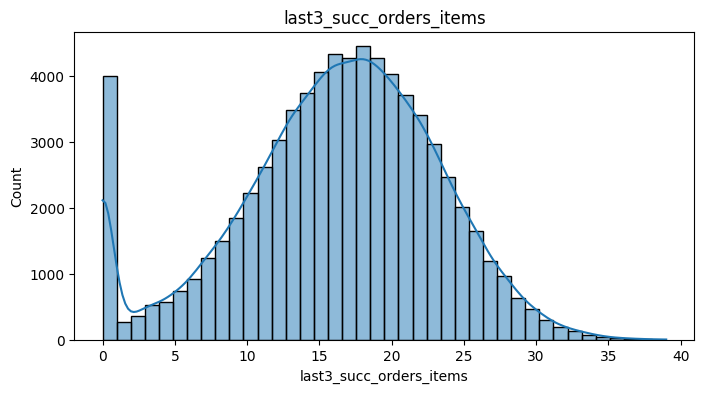

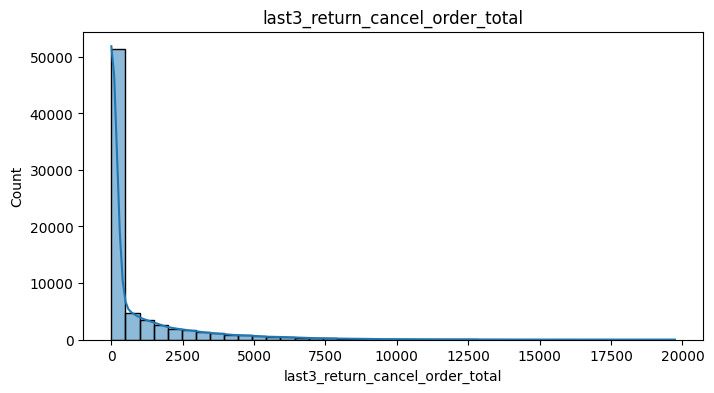

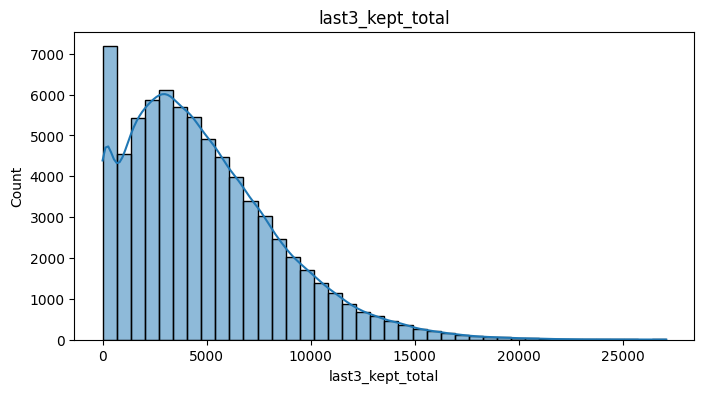

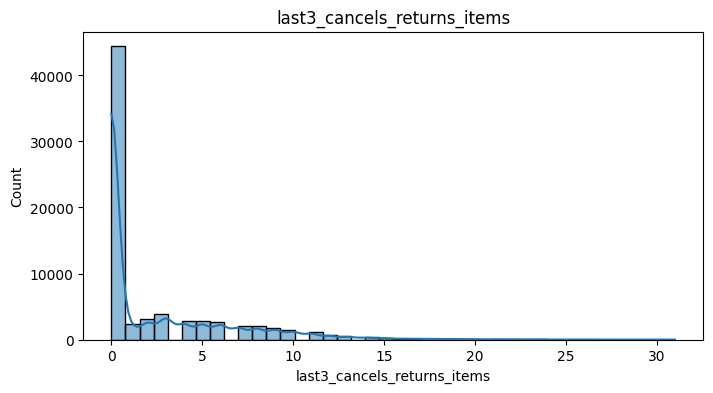

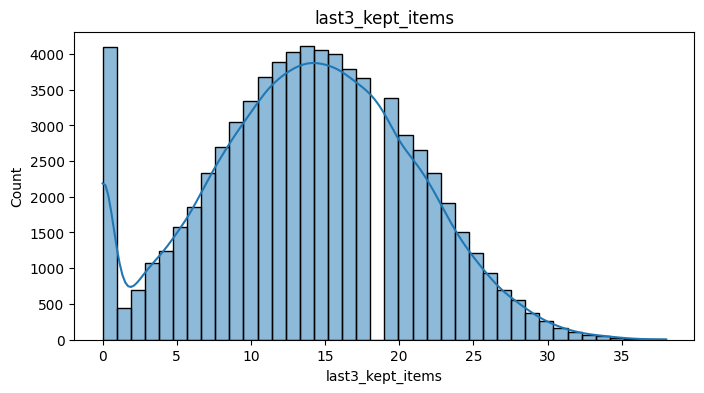

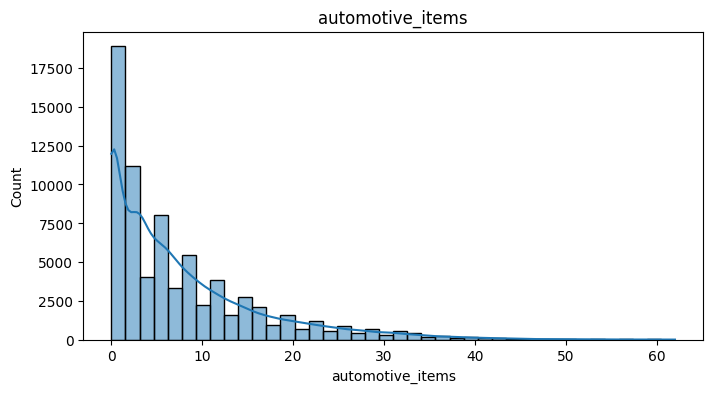

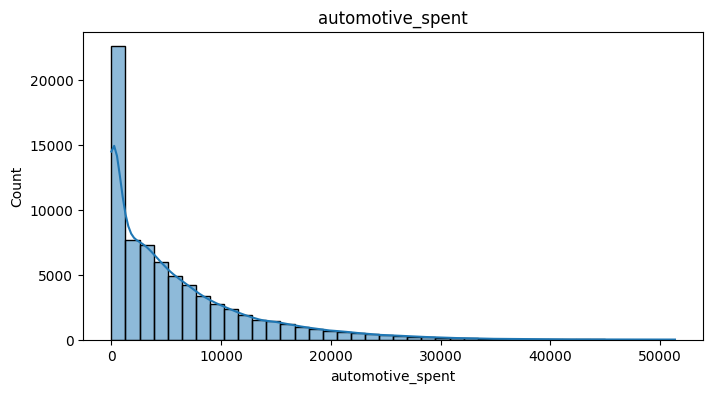

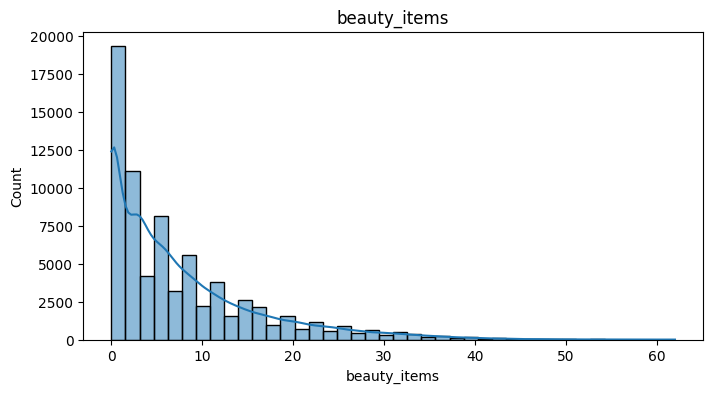

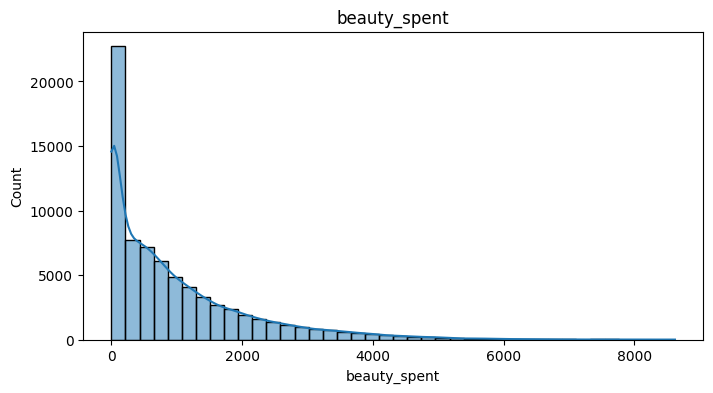

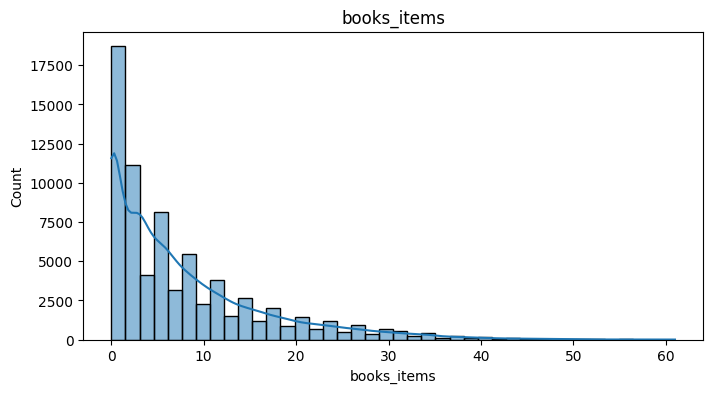

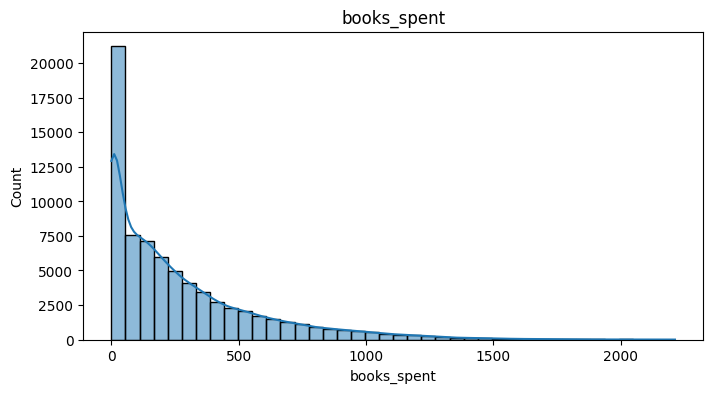

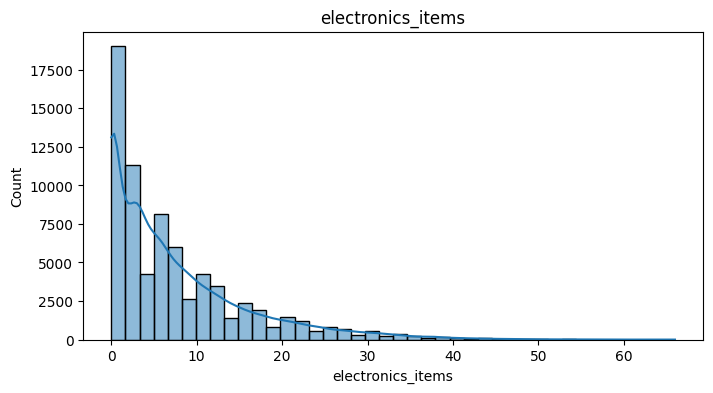

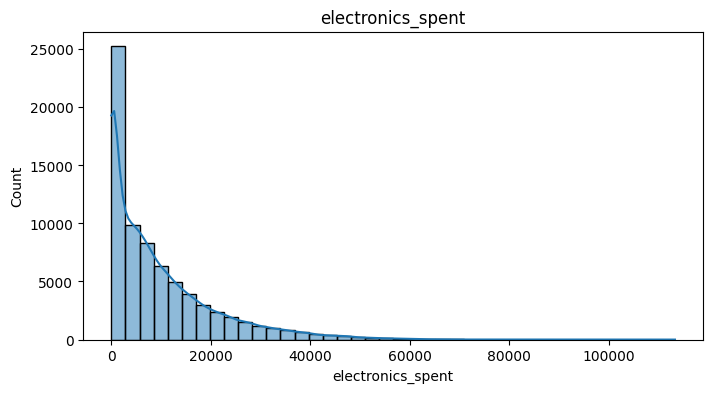

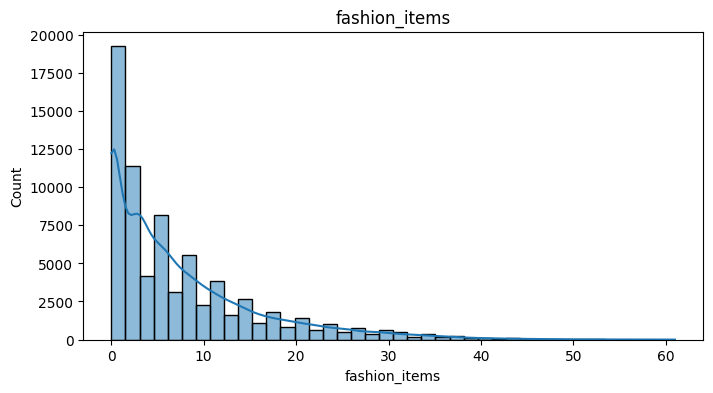

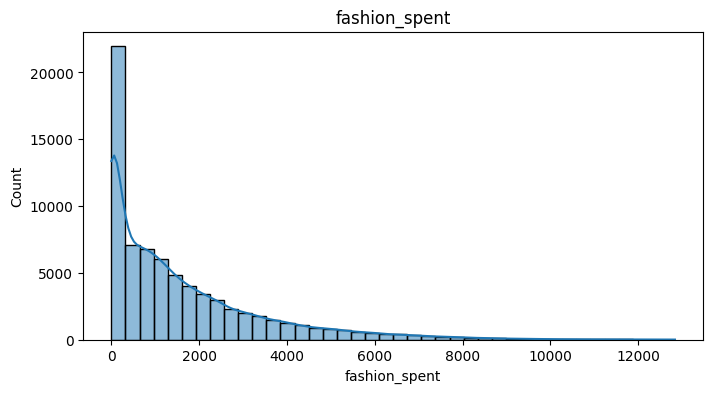

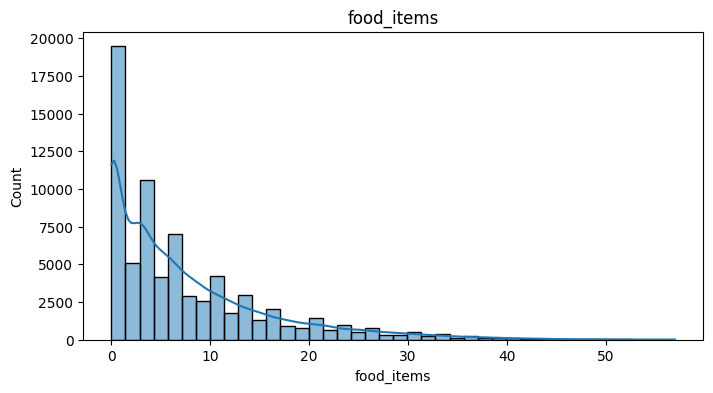

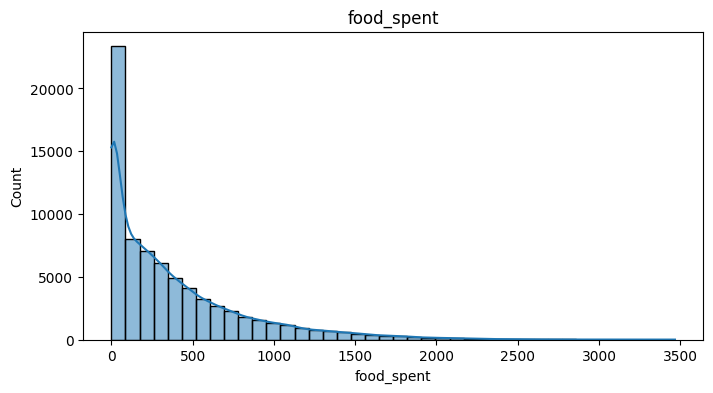

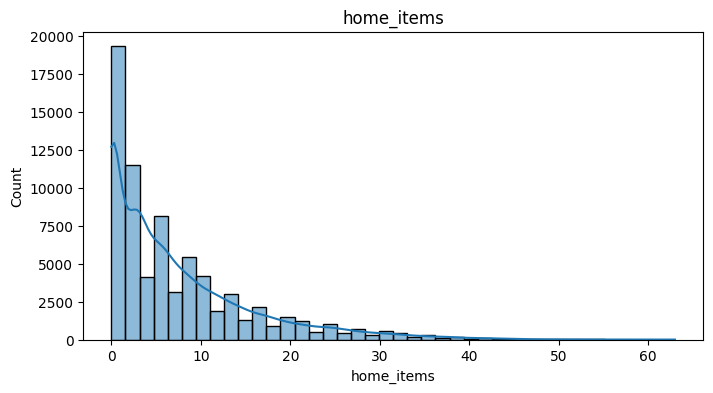

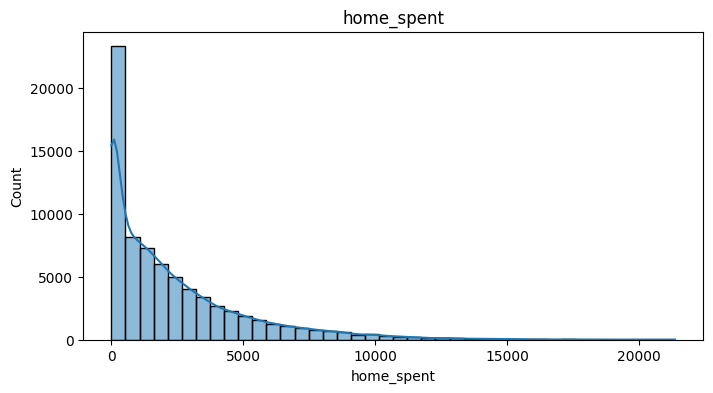

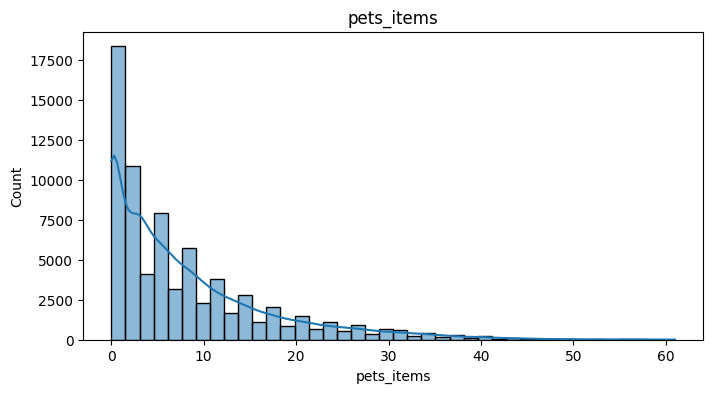

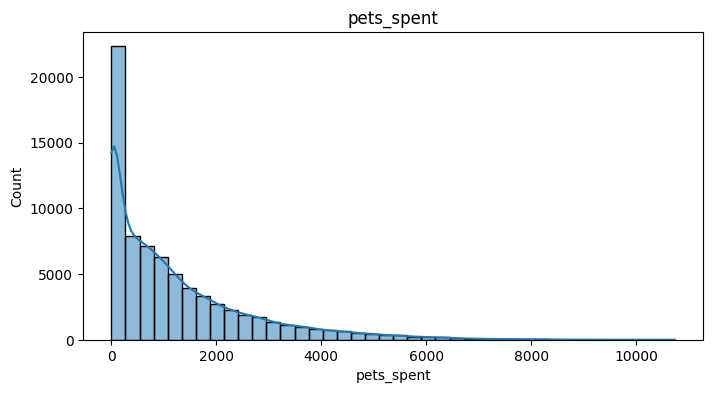

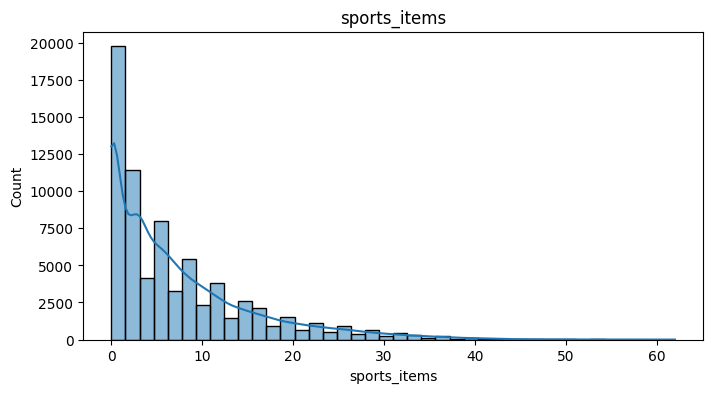

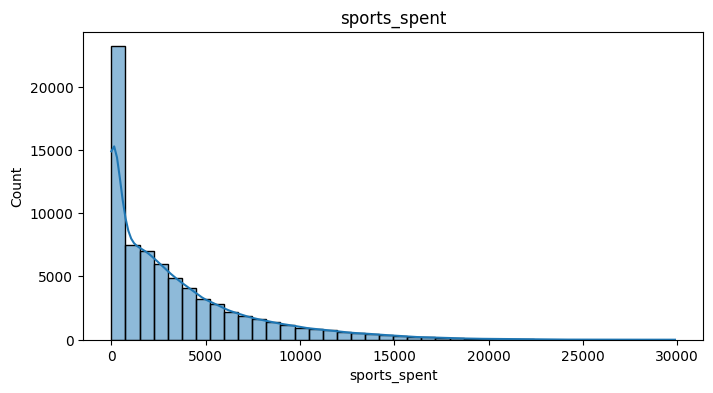

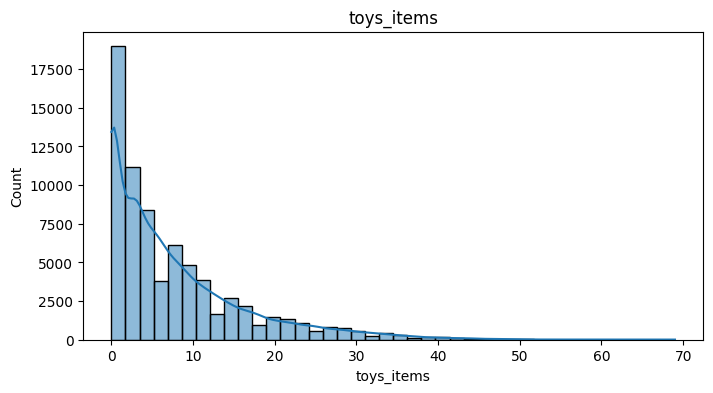

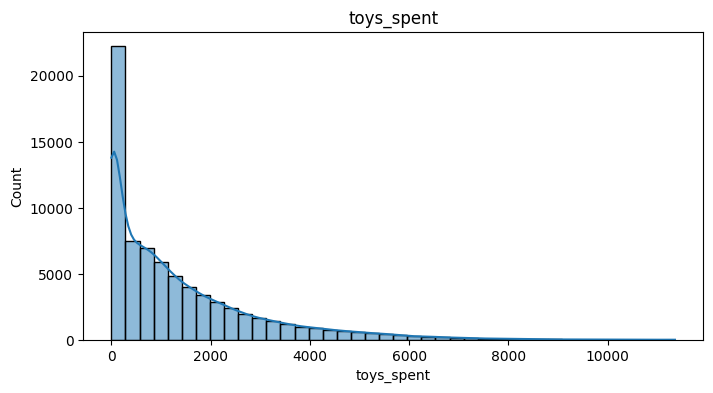

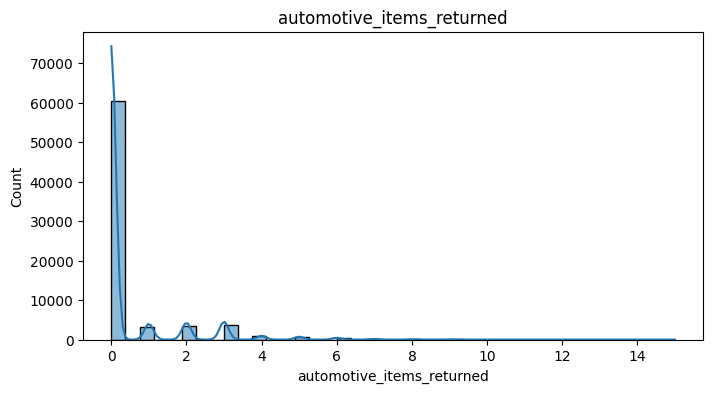

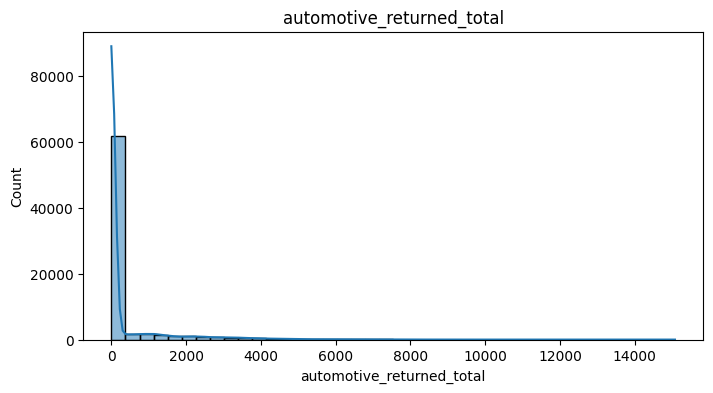

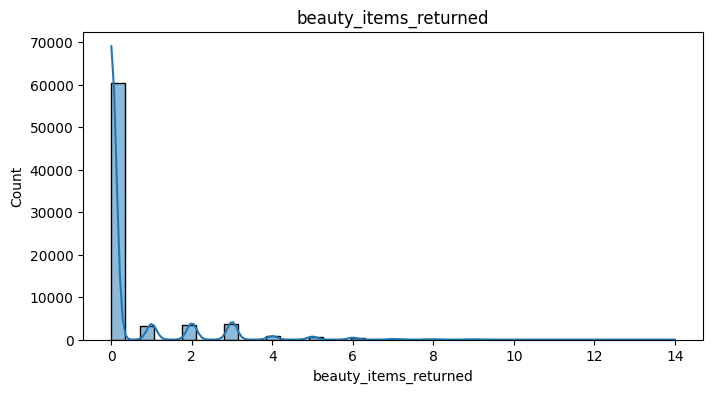

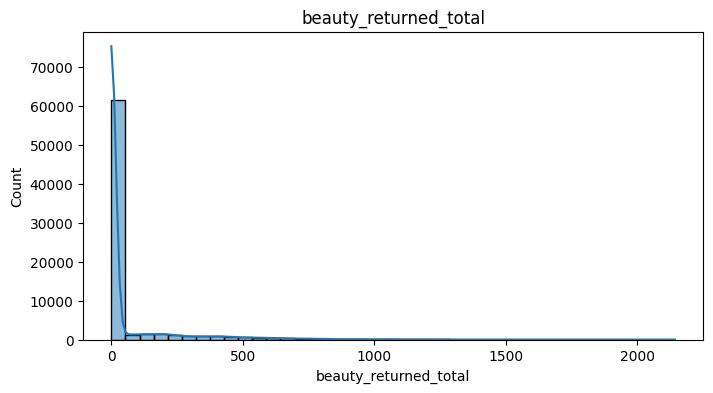

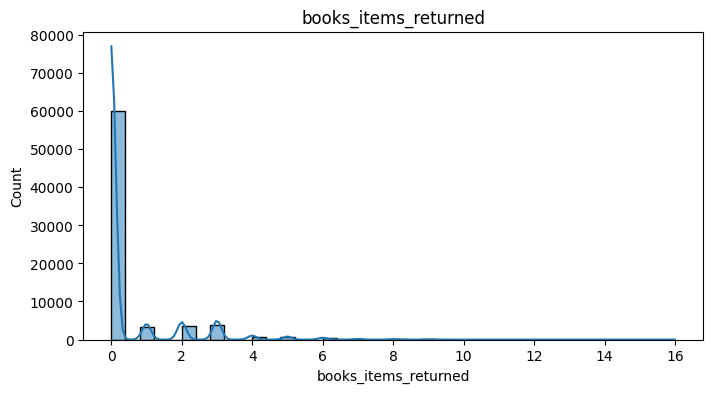

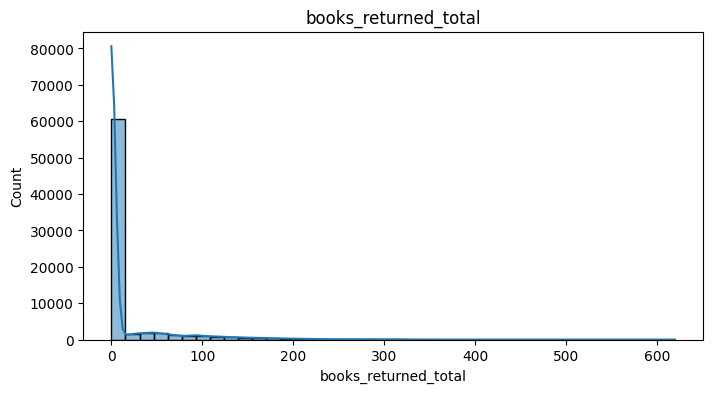

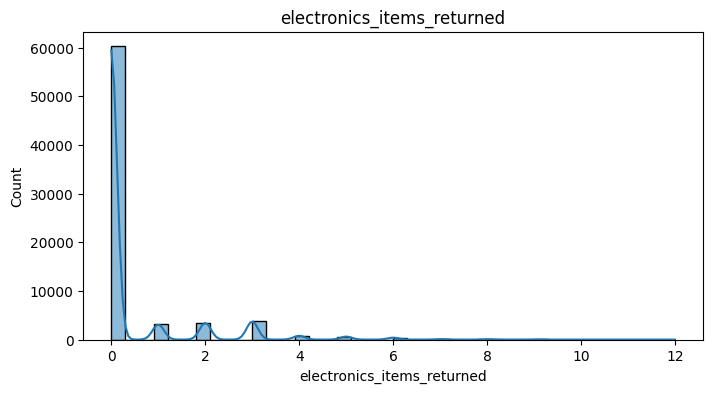

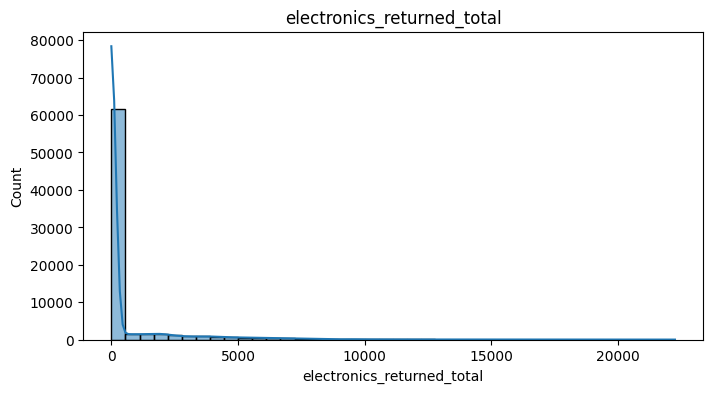

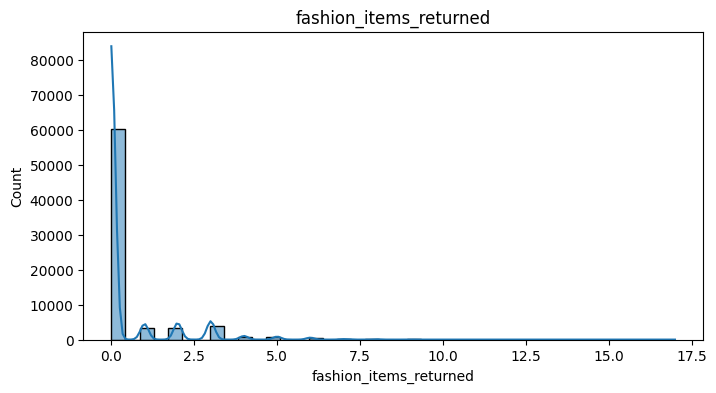

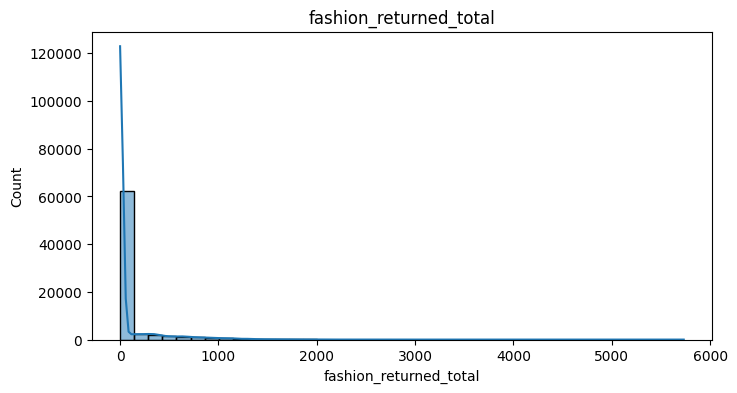

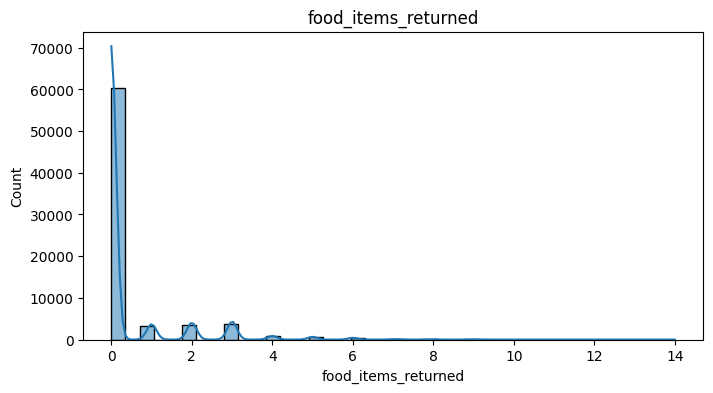

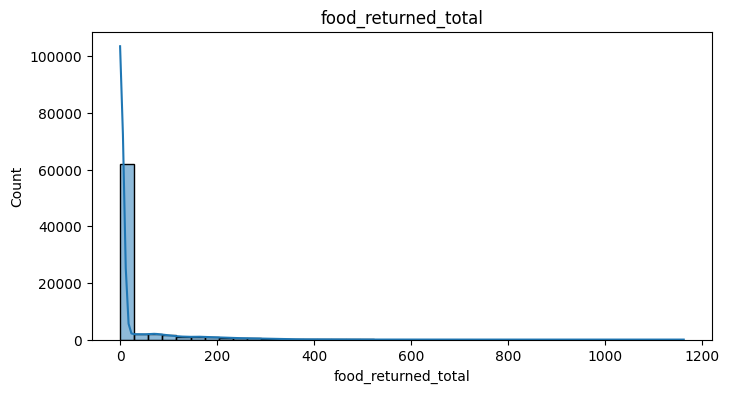

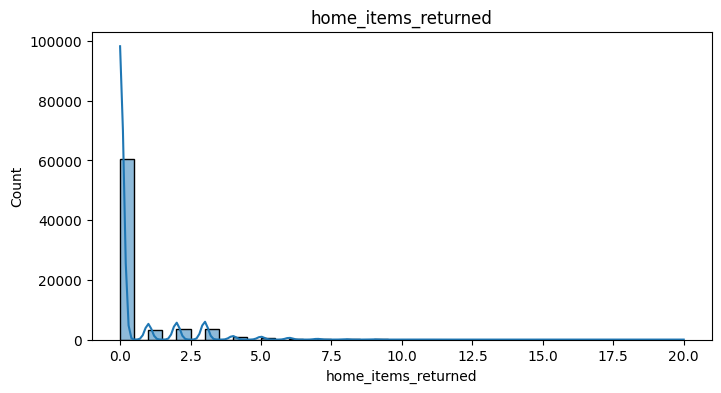

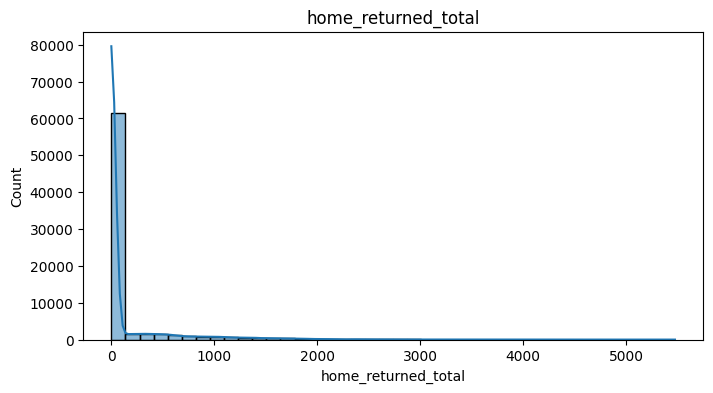

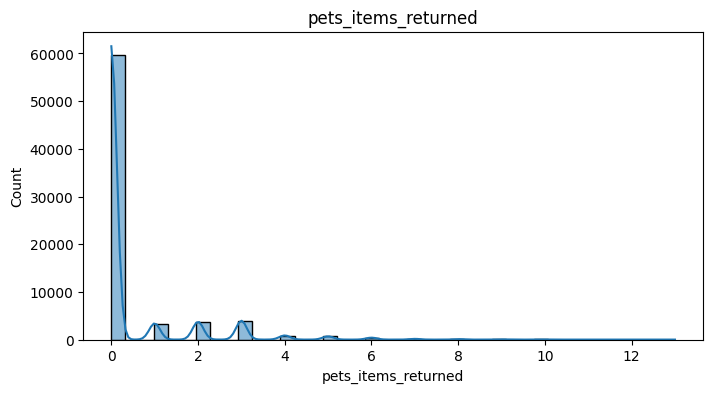

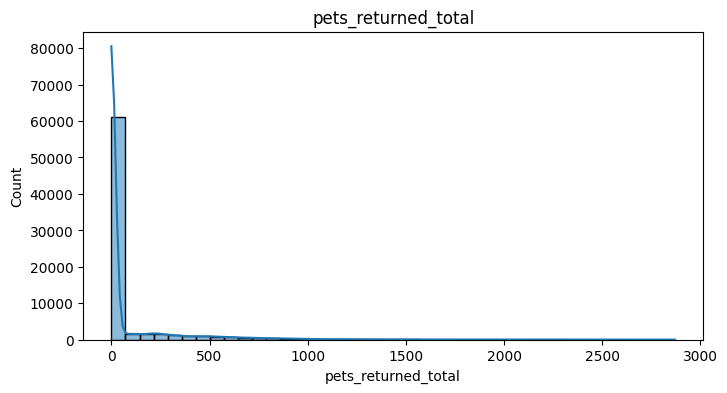

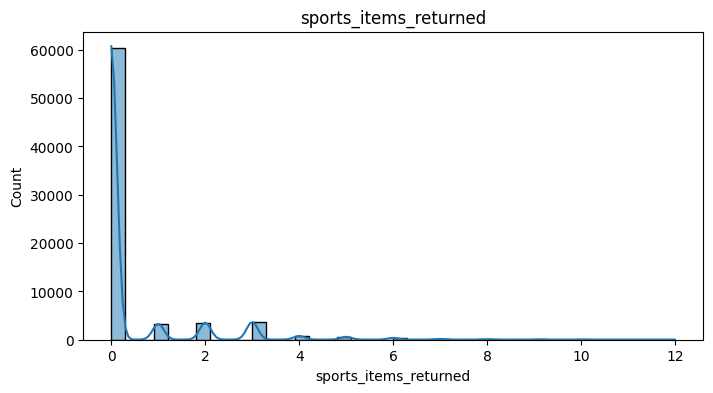

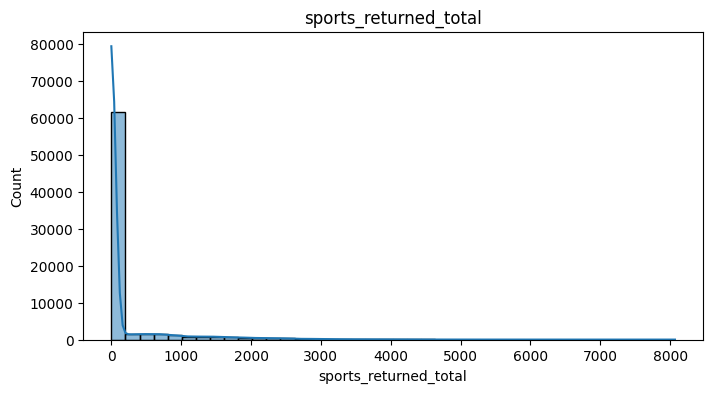

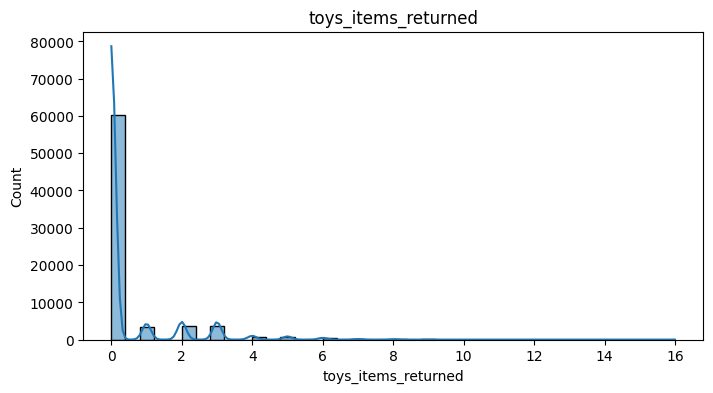

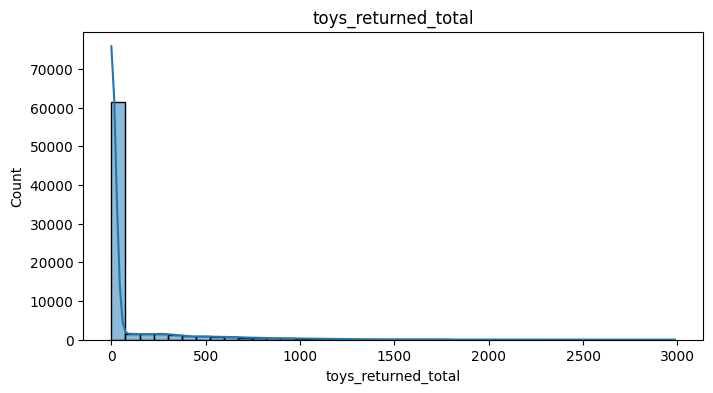

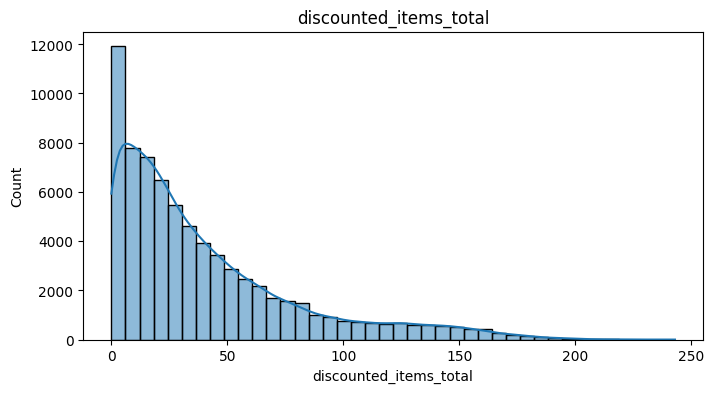

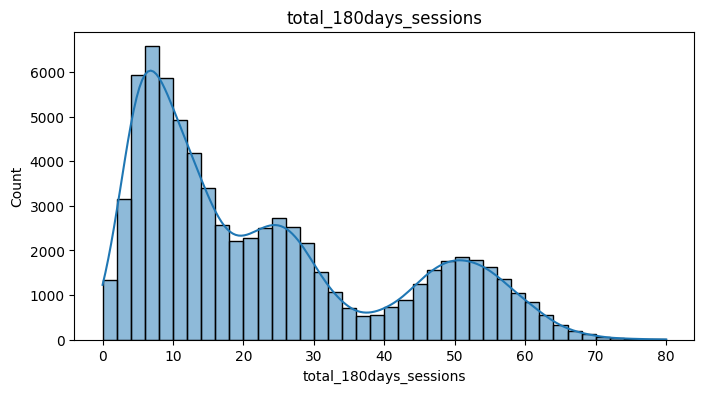

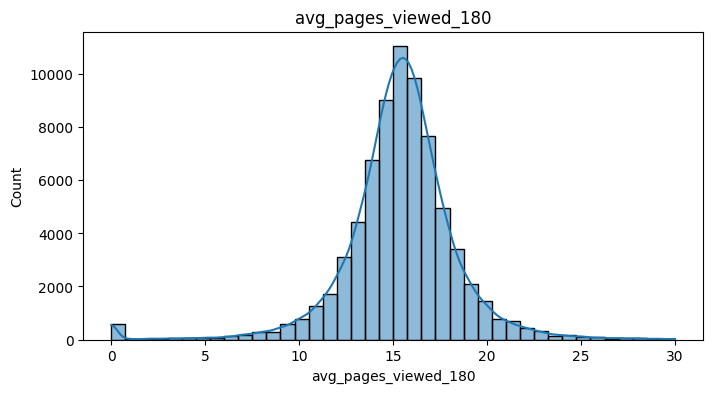

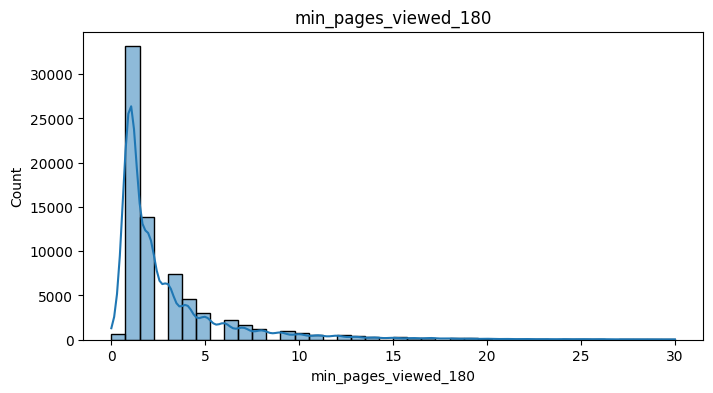

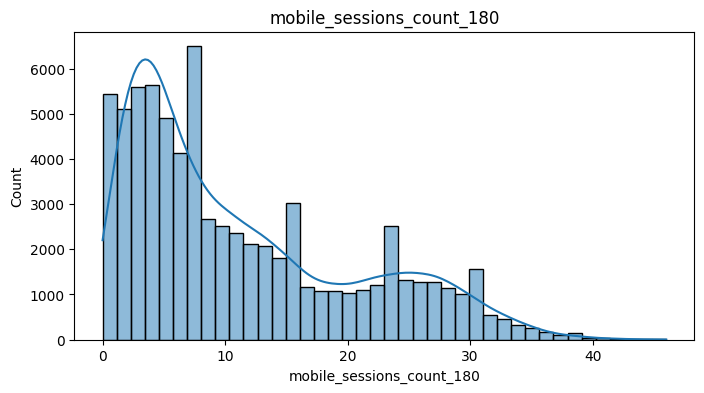

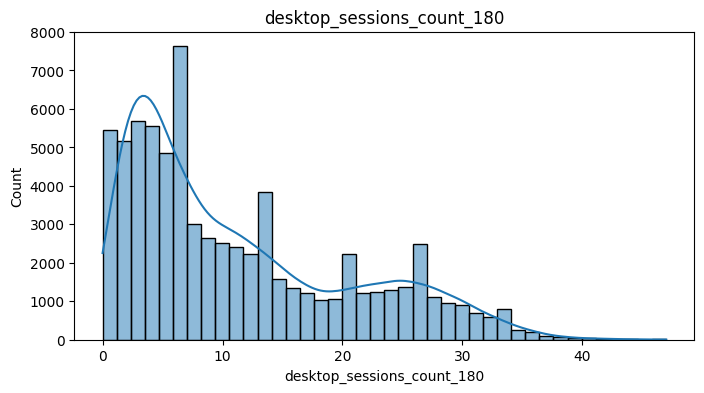

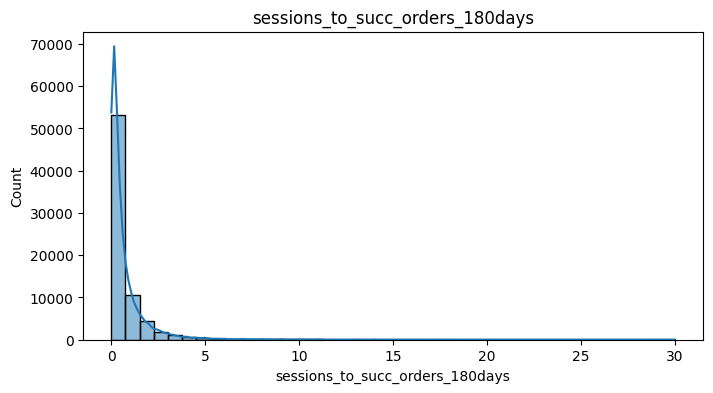

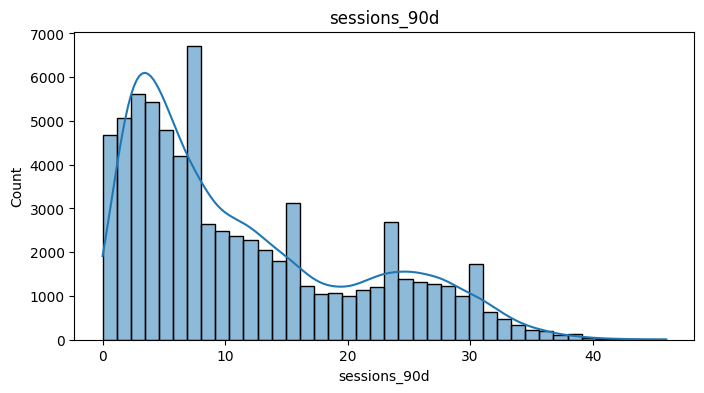

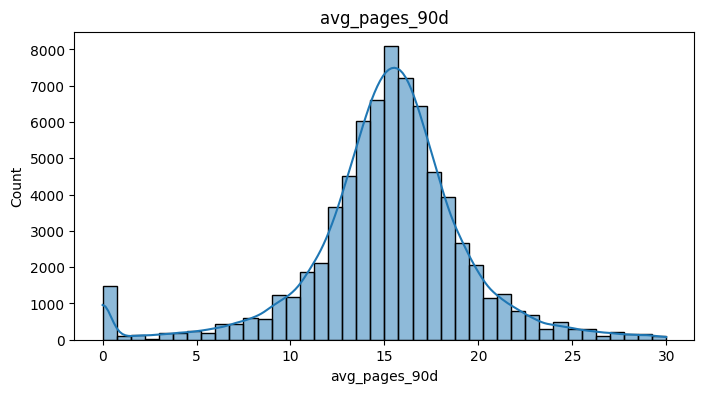

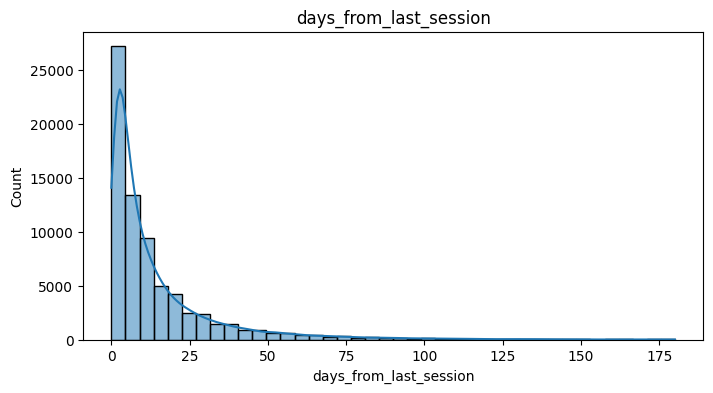

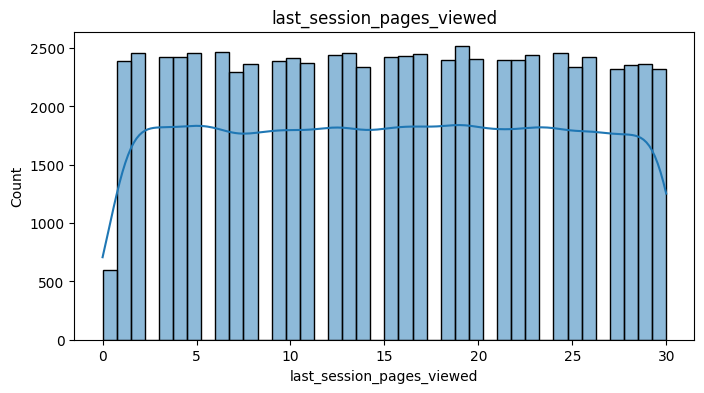

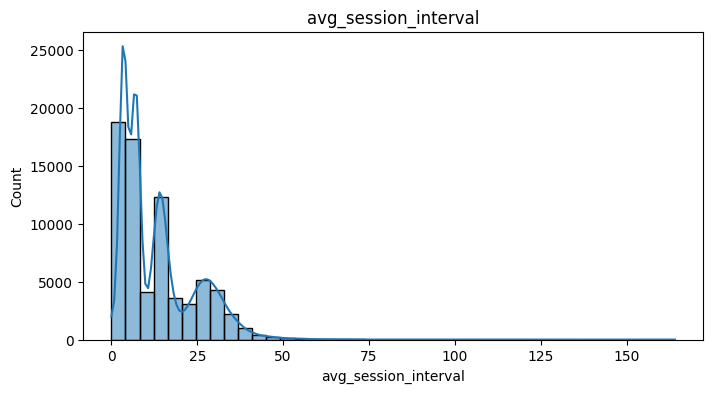

In [ ]:
for col in X_train.select_dtypes(include=['int64', 'float64']).columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_train[col], bins=40, kde=True)
    plt.title(col)
    plt.show()

In [ ]:
train_set = X_train.merge(y_train, on='customer_id')
train_set = train_set.drop(columns=['customer_id'])


The following cell computes the mode value of birth_date, as it can contain Nan values according to the SQL table creation. This mode will later be used to impute possible Nan values

In [ ]:
train_set['birth_date'] = pd.to_datetime(train_set['birth_date'])

birth_mode = train_set['birth_date'].mode()[0]

birth_mode

Timestamp('1949-12-15 00:00:00')

In [ ]:
train_set['birth_date'] = pd.to_datetime(train_set['birth_date'])
reference_date = pd.to_datetime('2026-01-01')
train_set['client_age'] = ((reference_date - train_set['birth_date']).dt.days // 365)
train_set = train_set.drop(columns=['birth_date'])
train_set['gender'] = train_set['gender'].replace({'Male': 0, 'Female': 1})
train_set = train_set.drop(columns = ['country', 'city'])

Getting to know the data, but taking no rushy decisions because of low/high MI value

In [ ]:
mi = mutual_info_classif(train_set.drop(columns=['target']), train_set['target'])
pd.Series(mi, index=train_set.drop(columns=['target']).columns).sort_values(ascending=False)


,0
shopping_frequency,0.060268
avg_last3_succ_interval,0.056040
succ_orders_count_90d,0.052698
shopping_frequency_90d,0.048580
discounted_items_total,0.041328
sessions_to_succ_orders_180days,0.038931
succ_orders_count,0.038224
total_succ_items_per_customer,0.035965
total_succ_items_per_customer_90d,0.034624
avg_items_per_order_90d,0.034025


In [ ]:
#Compute ratio function
def safe_division(numerator, denominator, default_value=0):
    return (
        (numerator / denominator)
        .replace([np.inf, -np.inf], default_value)
        .fillna(default_value)
    )

Data histograms revealed many features have many 0 values. The following cell computes the percent of 0 values in each feature. Features with approximately less than 60% of *non 0* values will not be taken into account while creating *ratios* due to equality of different situations (different behaviour signals both result in 0)

In [ ]:

zero_pct = (train_set.drop(columns = ['target']) == 0).sum() / len(train_set.drop(columns = ['target'])) * 100
nonzero_pct = (train_set.drop(columns = ['target']) != 0).sum() / len(train_set.drop(columns = ['target'])) * 100

stats = pd.DataFrame({
    'zero_pct': zero_pct.round(2),
    'nonzero_pct': nonzero_pct.round(2)
})


stats_sorted = stats.sort_values('zero_pct')

stats_sorted


,zero_pct,nonzero_pct
account_age_days,0.00,100.00
client_age,0.00,100.00
days_from_last_session,0.82,99.18
last_session_pages_viewed,0.82,99.18
min_pages_viewed_180,0.82,99.18
total_180days_sessions,0.82,99.18
avg_pages_viewed_180,0.82,99.18
avg_session_interval,1.48,98.52
sessions_90d,2.02,97.98
avg_pages_90d,2.02,97.98


In [ ]:
train_set["last_session_pages_to_avg90"] = safe_division(
    train_set["last_session_pages_viewed"],
    train_set["avg_pages_90d"]
)

train_set["sessions_90d_to_180"] = safe_division(
    train_set["sessions_90d"],
    train_set["total_180days_sessions"]
)

train_set["avg_pages_90d_to_180"] = safe_division(
    train_set["avg_pages_90d"],
    train_set["avg_pages_viewed_180"]
)

train_set["mobile_share"] = safe_division(
    train_set["mobile_sessions_count_180"],
    train_set["desktop_sessions_count_180"] + train_set["mobile_sessions_count_180"]
)

train_set["last_kept_items_ratio"] = safe_division(
    train_set["last_succ_kept_order_items"],
    train_set["last_succ_order_items"]
)

train_set["last_kept_value_ratio"] = safe_division(
    train_set["last_succ_kept_order_total"],
    train_set["last_succ_order_total"]
)

train_set["last3_kept_items_ratio"] = safe_division(
    train_set["last3_kept_items"],
    train_set["last3_kept_items"] + train_set["last3_cancels_returns_items"]
)

train_set["last3_kept_value_ratio"] = safe_division(
    train_set["last3_kept_total"],
    train_set["last3_kept_total"] + train_set["last3_return_cancel_order_total"]
)

train_set['last3_succ_kept_value_to_avg_ratio'] = safe_division(
    train_set["last3_succ_orders_kept_total"],
    3*(train_set["avg_order_value"])
)

train_set['last_succ_kept_value_to_avg_ratio'] = safe_division(
    train_set["last_succ_kept_order_total"],
    (train_set["avg_order_value"])
)

train_set["avg_items_per_order_recent_ratio"] = safe_division(
    train_set["avg_items_per_order_90d"],
    train_set["avg_items_per_order"]
)

train_set["avg_order_value_recent_ratio"] = safe_division(
    train_set["avg_order_value_90d"],
    train_set["avg_order_value"]
)

train_set["succ_items_recent_ratio"] = safe_division(
    train_set["total_succ_items_per_customer_90d"],
    train_set["total_succ_items_per_customer"]
)

train_set["sessions_per_success_order_90d"] = safe_division(
    train_set["sessions_90d"],
    train_set["succ_orders_count_90d"]
)

train_set["min_order_value_delta"] = (
    train_set["min_order_value_90d"] -
    train_set["min_order_value"]
)

train_set["succ_orders_per_account_age"] = safe_division(
    train_set["succ_orders_count"],
    train_set["account_age_days"]
)

Checking if the created features are somehow good

In [ ]:

mi2 = mutual_info_classif(train_set.drop(columns=['target']), train_set['target'])
pd.Series(mi2, index=train_set.drop(columns=['target']).columns).sort_values(ascending=False)

,0
succ_orders_per_account_age,0.067234
shopping_frequency,0.061520
avg_last3_succ_interval,0.054087
succ_orders_count_90d,0.046641
shopping_frequency_90d,0.043732
discounted_items_total,0.042264
sessions_to_succ_orders_180days,0.039025
succ_orders_count,0.035521
total_succ_items_per_customer,0.035335
avg_items_per_order_90d,0.035246


Checking if newly created created features are not highly correalted.

NOTE: some of our features initially present in the dataset are highly correlated, but they bring different signals to our model (e.g. items_count and items_total), so we keep them since our model is not a linear one.

In [ ]:

corr_matrix = train_set.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper.stack()
         .sort_values(ascending=False)
)

high_corr = high_corr[high_corr > 0.95]

high_corr

succ_orders_count                   total_succ_items_per_customer    0.988041
total_succ_items_per_customer       discounted_items_total           0.979319
last_succ_kept_order_total          last_succ_order_total            0.977597
last3_succ_orders_kept_total        last3_succ_orders_total          0.976522
last_kept_items_ratio               last_kept_value_ratio            0.975999
books_items                         books_spent                      0.974963
succ_orders_count                   discounted_items_total           0.971256
last3_succ_orders_kept_items_total  last3_succ_orders_items          0.970472
total_180days_sessions              mobile_sessions_count_180        0.966879
                                    desktop_sessions_count_180       0.966868
fashion_items                       fashion_spent                    0.964103
beauty_items                        beauty_spent                     0.963243
pets_items                          pets_spent                       0.961943
electronics_items                   electronics_spent                0.961255
toys_items                          toys_spent                       0.960403
last_succ_kept_order_items          last_succ_order_items            0.960304
food_items                          food_spent                       0.960148
home_items                          home_spent                       0.960130
automotive_items                    automotive_spent                 0.959443
sports_items                        sports_spent                     0.959196
total_180days_sessions              sessions_90d                     0.955430
dtype: float64

Creating a validation set

In [ ]:
X_temp = train_set.drop(columns=['target'])
y_temp = train_set['target']

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, stratify=y_temp, random_state=42)

In [ ]:
X_train.shape

(61823, 109)

In [ ]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

Computing sample weight to help model with imbalance

In [ ]:
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

sample_weights.shape

(61823,)

In [ ]:
np.unique(sample_weights, return_counts=True)

(array([  0.46598378,   1.17818688, 190.8117284 ]),
 array([44224, 17491,   108]))

Initial multiclass XGBoost test parametrs

In [ ]:
model_ini = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",


    n_estimators=400,

    max_depth=5,
    min_child_weight=3,

    subsample=0.8,
    colsample_bytree=0.8,

    n_jobs=-1,
    random_state=42
)

model_ini.fit(
    X_train, y_train_enc,
    sample_weight=sample_weights
)

y_val_pred = model_ini.predict(X_val)

cm_ini = confusion_matrix(le.inverse_transform(y_val_enc), le.inverse_transform(y_val_pred))
cm_ini_df = pd.DataFrame(cm_ini, index=le.classes_, columns=le.classes_)
cm_ini_df

,ACTIVE,AT-RISK,CHURNED
ACTIVE,5334,2470,0
AT-RISK,1275,1812,0
CHURNED,10,9,0


In [ ]:
y_train_pred = model_ini.predict(X_train)
cm_ini_tr = confusion_matrix(le.inverse_transform(y_train_enc), le.inverse_transform(y_train_pred))
cm_ini_tr_df = pd.DataFrame(cm_ini_tr, index=le.classes_, columns=le.classes_)
cm_ini_tr_df

,ACTIVE,AT-RISK,CHURNED
ACTIVE,36953,7271,0
AT-RISK,455,17036,0
CHURNED,0,0,108


In [ ]:
y_proba = model_ini.predict_proba(X_val)
churn_prob = y_proba[:, 2]

np.percentile(churn_prob, [90, 95, 99, 99.5, 99.9, 100])

array([1.33375476e-04, 5.07241741e-04, 5.20767966e-03, 1.13277837e-02,
       4.21023816e-02, 3.46390009e-01])

Overfitting detected, checking if early stopping and some regularization (both L1 and L2 since there are lots of features)  will help

In [ ]:
model_ini = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",


    n_estimators=1000,
    early_stopping_rounds=50,


    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    reg_alpha=0.3,
    reg_lambda=1.0,
    gamma=0.2,

    subsample=0.9,
    colsample_bytree=0.7,

    n_jobs=-1,
    random_state=42
)

model_ini.fit(
    X_train, y_train_enc,
    sample_weight=sample_weights,
    eval_set=[(X_train, y_train_enc), (X_val, y_val_enc)],
    verbose=True
)

y_val_pred = model_ini.predict(X_val)

cm_ini = confusion_matrix(
    le.inverse_transform(y_val_enc),
    le.inverse_transform(y_val_pred)
)

cm_ini_df = pd.DataFrame(cm_ini, index=le.classes_, columns=le.classes_)
cm_ini_df


[0]	validation_0-mlogloss:1.07895	validation_1-mlogloss:1.07908
[1]	validation_0-mlogloss:1.06002	validation_1-mlogloss:1.06037
[2]	validation_0-mlogloss:1.04286	validation_1-mlogloss:1.04342
[3]	validation_0-mlogloss:1.02796	validation_1-mlogloss:1.02852
[4]	validation_0-mlogloss:1.01405	validation_1-mlogloss:1.01453
[5]	validation_0-mlogloss:1.00021	validation_1-mlogloss:1.00087
[6]	validation_0-mlogloss:0.98676	validation_1-mlogloss:0.98744
[7]	validation_0-mlogloss:0.97498	validation_1-mlogloss:0.97574
[8]	validation_0-mlogloss:0.96434	validation_1-mlogloss:0.96517
[9]	validation_0-mlogloss:0.95362	validation_1-mlogloss:0.95469
[10]	validation_0-mlogloss:0.94402	validation_1-mlogloss:0.94512
[11]	validation_0-mlogloss:0.93485	validation_1-mlogloss:0.93600
[12]	validation_0-mlogloss:0.92633	validation_1-mlogloss:0.92758
[13]	validation_0-mlogloss:0.91852	validation_1-mlogloss:0.91974
[14]	validation_0-mlogloss:0.91074	validation_1-mlogloss:0.91213
[15]	validation_0-mlogloss:0.90369	

,ACTIVE,AT-RISK,CHURNED
ACTIVE,4845,2958,1
AT-RISK,894,2193,0
CHURNED,7,12,0


Model performs better now, but it still handles AT-RISK and especially CHURNED clients poorly, giving lots of false alarms for active clients at the same time. At this moment idea to make **two binary classifiers** pops up. The first one will classify client as ACTIVE(0) VS NON-ACTIVE(1),  and the second will classify NON-ACTIVE clients as AT-RISK(0) VS CHURN(1)

Model 1: ACTIVE(0), NON-ACTIVE(1)

In [ ]:
train_set_bin = train_set.copy()
train_set_bin['is_not_active'] = train_set_bin['target'].apply(lambda x: 1 if x != 'ACTIVE' else 0)

In [ ]:
X_temp_bin = train_set_bin.drop(columns=['target', 'is_not_active'])
y_temp_bin = train_set_bin['is_not_active']

In [ ]:

X_train_bin, X_val_bin, y_train_bin, y_val_bin = train_test_split(X_temp_bin, y_temp_bin, test_size=0.15, stratify=y_temp_bin, random_state=42)

In [ ]:
neg_count = (y_train_bin == 0).sum()
pos_count = (y_train_bin == 1).sum()
weight = neg_count / pos_count

model_bin = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",

    n_estimators=1000,
    early_stopping_rounds=80,
    learning_rate=0.05,

    max_depth=6,
    min_child_weight=3,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=weight,

    random_state=42
)

model_bin.fit(
    X_train_bin, y_train_bin,
    eval_set=[(X_train_bin, y_train_bin), (X_val_bin, y_val_bin)],
    verbose=True
)

print(f"Stopped at iteration: {model_bin.best_iteration}")
print(f"Best aucpr on val: {model_bin.best_score}")

[0]	validation_0-aucpr:0.46250	validation_1-aucpr:0.45237
[1]	validation_0-aucpr:0.47091	validation_1-aucpr:0.46368
[2]	validation_0-aucpr:0.47337	validation_1-aucpr:0.46603
[3]	validation_0-aucpr:0.47408	validation_1-aucpr:0.46760
[4]	validation_0-aucpr:0.47482	validation_1-aucpr:0.46738
[5]	validation_0-aucpr:0.47453	validation_1-aucpr:0.46794
[6]	validation_0-aucpr:0.47517	validation_1-aucpr:0.46895
[7]	validation_0-aucpr:0.47922	validation_1-aucpr:0.47066
[8]	validation_0-aucpr:0.47979	validation_1-aucpr:0.47113
[9]	validation_0-aucpr:0.47981	validation_1-aucpr:0.47103
[10]	validation_0-aucpr:0.47971	validation_1-aucpr:0.47068
[11]	validation_0-aucpr:0.48013	validation_1-aucpr:0.47110
[12]	validation_0-aucpr:0.48056	validation_1-aucpr:0.47129
[13]	validation_0-aucpr:0.48083	validation_1-aucpr:0.47133
[14]	validation_0-aucpr:0.48090	validation_1-aucpr:0.47200
[15]	validation_0-aucpr:0.48189	validation_1-aucpr:0.47361
[16]	validation_0-aucpr:0.48232	validation_1-aucpr:0.47290
[17]	va

In [ ]:
cm_bin = confusion_matrix(y_val_bin, model_bin.predict(X_val_bin))
cm_bin_df = pd.DataFrame(cm_bin, index=["Active", "Non-Active"], columns=["Active", "Non-Active"])
cm_bin_df


,Active,Non-Active
Active,4358,3446
Non-Active,698,2408


Model classifies non-active clients better than it used to, though giving more false alarms. It's not the final model though but the idea with 2 binary classifiers is more appeaking. The model parametrs can be tweaked later to achieve better performance. Right now this model will be used only to see SHAP values and confirm some assumptions about not really useful features resulting in possible feature selection

In [ ]:
explainer_act_nact= shap.TreeExplainer(model_bin)
shap_values = explainer_act_nact.shap_values(X_train_bin)

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [ ]:
shap_importance = pd.DataFrame({
    'feature': X_train_bin.columns,
    'importance': np.abs(shap_values).mean(axis=0)
})
shap_importance = shap_importance.sort_values(by='importance', ascending=False)

shap_importance


,feature,importance
108,succ_orders_per_account_age,0.598193
0,account_age_days,0.112709
2,shopping_frequency,0.080724
11,shopping_frequency_90d,0.078236
91,avg_session_interval,0.050811
3,unsuccessful_orders_count,0.050485
13,succ_orders_count_90d,0.037178
28,days_from_last_cancel,0.031075
31,avg_last3_succ_interval,0.023857
105,succ_items_recent_ratio,0.022656


SHAP confirmed that features referring to category items returns , as well as gender feature are not really important and we can drop them and see if it affected the performance in a bad way. Other features are preserved even if they have occasional low SHAP values, since they describe client's behaviour. I also thought category features other than items returned were to be unimportant, yet it turns out the model uses them, so i don't risk.

Model B: AT-RISK(0), CHURNED(1)

In [ ]:
train_set_risk_churn = train_set.copy()
train_set_risk_churn = train_set_risk_churn[train_set_risk_churn['target'] != 'ACTIVE']
train_set_risk_churn['is_churn'] = train_set_risk_churn['target'].apply(lambda x: 1 if x == 'CHURNED' else 0)

In [ ]:
X_risk_churn = train_set_risk_churn.drop(columns=['target', 'is_churn'])
y_risk_churn = train_set_risk_churn['is_churn']

In [ ]:
X_risk_churn_train, X_risk_churn_val, y_risk_churn_train, y_risk_churn_val = train_test_split(X_risk_churn, y_risk_churn, test_size=0.15, stratify=y_risk_churn, random_state=42)

In [ ]:
neg_count = (y_risk_churn_train == 0).sum()
pos_count = (y_risk_churn_train == 1).sum()
weight = neg_count / pos_count

model_churn_risk = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",

    n_estimators=1000,
    early_stopping_rounds=40,
    learning_rate=0.05,

    max_depth=5,
    min_child_weight=3,

    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=weight,

    random_state=42
)

model_churn_risk.fit(
    X_risk_churn_train, y_risk_churn_train,
    eval_set=[(X_risk_churn_train, y_risk_churn_train), (X_risk_churn_val, y_risk_churn_val)],
    verbose=True
)

print(f"Stopped at iteration: {model_churn_risk.best_iteration}")
print(f"Best aucpr on val: {model_churn_risk.best_score}")

[0]	validation_0-aucpr:0.03415	validation_1-aucpr:0.01525
[1]	validation_0-aucpr:0.05059	validation_1-aucpr:0.01455
[2]	validation_0-aucpr:0.07315	validation_1-aucpr:0.01801
[3]	validation_0-aucpr:0.09158	validation_1-aucpr:0.01848
[4]	validation_0-aucpr:0.07726	validation_1-aucpr:0.01823
[5]	validation_0-aucpr:0.10549	validation_1-aucpr:0.02212
[6]	validation_0-aucpr:0.12092	validation_1-aucpr:0.02389
[7]	validation_0-aucpr:0.11958	validation_1-aucpr:0.02360
[8]	validation_0-aucpr:0.12693	validation_1-aucpr:0.02393
[9]	validation_0-aucpr:0.13488	validation_1-aucpr:0.02448
[10]	validation_0-aucpr:0.15052	validation_1-aucpr:0.02326
[11]	validation_0-aucpr:0.17228	validation_1-aucpr:0.02246
[12]	validation_0-aucpr:0.17374	validation_1-aucpr:0.02297
[13]	validation_0-aucpr:0.18086	validation_1-aucpr:0.02310
[14]	validation_0-aucpr:0.18717	validation_1-aucpr:0.02116
[15]	validation_0-aucpr:0.17551	validation_1-aucpr:0.02167
[16]	validation_0-aucpr:0.17350	validation_1-aucpr:0.02196
[17]	va

In [ ]:
cm_risk_ch = confusion_matrix(y_risk_churn_val, model_churn_risk.predict(X_risk_churn_val))
cm_risk_churn_df = pd.DataFrame(cm_risk_ch, index=["At-risk", "Churned"], columns=["At-risk", "Churned"])
cm_risk_churn_df


,At-risk,Churned
At-risk,2685,402
Churned,8,11


In [ ]:
print(model_churn_risk.predict_proba(X_risk_churn_val)[:, 1].max())
print(np.percentile(model_churn_risk.predict_proba(X_risk_churn_val)[:, 1], [90, 95, 99]))


0.7961768
[0.58054703 0.68749547 0.77090318]


Churned clients are finally classifiable, so we can look at model's B SHAP values as well

In [ ]:

explainer_churn_risk = shap.TreeExplainer(model_churn_risk)
shap_values = explainer_churn_risk.shap_values(X_risk_churn_train)

shap_importance = pd.DataFrame({
    'feature': X_risk_churn_train.columns,
    'importance': np.abs(shap_values).mean(axis=0)
})
shap_importance = shap_importance.sort_values(by='importance', ascending=False)

shap_importance


,feature,importance
91,avg_session_interval,0.849592
2,shopping_frequency,0.165308
87,sessions_90d,0.163734
31,avg_last3_succ_interval,0.106275
86,sessions_to_succ_orders_180days,0.096356
81,total_180days_sessions,0.060740
92,client_age,0.038220
14,avg_order_value_90d,0.037667
20,last_suc_order_interval,0.037587
89,days_from_last_session,0.034032


0 value SHAP features are going to be dropped since model doesn't use them

In [ ]:
y_train_A = y_train_bin.copy()
y_val_A = y_val_bin.copy()

cols_to_drop = []

for col in X_train_bin.columns:
    if col == "gender":
        cols_to_drop.append(col)

    elif col.endswith("_items_returned"):
        cols_to_drop.append(col)

X_train_A = X_train_bin.drop(columns=cols_to_drop)
X_val_A = X_val_bin.drop(columns=cols_to_drop)

print("Deleted columns:", cols_to_drop)
print("Total deleted:", len(cols_to_drop))


Deleted columns: ['gender', 'automotive_items_returned', 'beauty_items_returned', 'books_items_returned', 'electronics_items_returned', 'fashion_items_returned', 'food_items_returned', 'home_items_returned', 'pets_items_returned', 'sports_items_returned', 'toys_items_returned']
Total deleted: 11


Checking model A performance after dropping some features considered to have low value to the model

In [ ]:
neg_count = (y_train_A == 0).sum()
pos_count = (y_train_A == 1).sum()
weight = neg_count / pos_count

model_A = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",

    n_estimators=1000,
    early_stopping_rounds=80,
    learning_rate=0.05,

    max_depth=6,
    min_child_weight=3,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=weight,

    random_state=42
)

model_A.fit(
    X_train_A, y_train_A,
    eval_set=[(X_train_A, y_train_A), (X_val_A, y_val_A)],
    verbose=True
)

print(f"Stopped at iteration: {model_A.best_iteration}")
print(f"Best aucpr on val: {model_A.best_score}")

from sklearn.metrics import confusion_matrix

cm_A = confusion_matrix(y_val_A, model_A.predict(X_val_A))
cm_A_df = pd.DataFrame(cm_A, index=["Active", "Non-Active"], columns=["Active", "Non-Active"])
cm_A_df


[0]	validation_0-aucpr:0.46700	validation_1-aucpr:0.45498
[1]	validation_0-aucpr:0.47116	validation_1-aucpr:0.46264
[2]	validation_0-aucpr:0.47461	validation_1-aucpr:0.46317
[3]	validation_0-aucpr:0.47535	validation_1-aucpr:0.45964
[4]	validation_0-aucpr:0.47725	validation_1-aucpr:0.46517
[5]	validation_0-aucpr:0.47873	validation_1-aucpr:0.46713
[6]	validation_0-aucpr:0.47924	validation_1-aucpr:0.46771
[7]	validation_0-aucpr:0.47885	validation_1-aucpr:0.46727
[8]	validation_0-aucpr:0.47988	validation_1-aucpr:0.46772
[9]	validation_0-aucpr:0.48019	validation_1-aucpr:0.46861
[10]	validation_0-aucpr:0.48092	validation_1-aucpr:0.46845
[11]	validation_0-aucpr:0.48074	validation_1-aucpr:0.46883
[12]	validation_0-aucpr:0.48105	validation_1-aucpr:0.46894
[13]	validation_0-aucpr:0.48131	validation_1-aucpr:0.47043
[14]	validation_0-aucpr:0.48141	validation_1-aucpr:0.47074
[15]	validation_0-aucpr:0.48385	validation_1-aucpr:0.47202
[16]	validation_0-aucpr:0.48380	validation_1-aucpr:0.47226
[17]	va

,Active,Non-Active
Active,4272,3532
Non-Active,661,2445


Model's PRAUC is almost the same, so we can continue to improve model's performance without this features being in the dataset

Training model B after dropping 0 SHAP features

In [ ]:
y_train_B = y_risk_churn_train.copy()
y_val_B = y_risk_churn_val.copy()

zero_shap_features = [
    "beauty_items",
    "automotive_spent",
    "last3_kept_total",
    "last3_cancels_returns_items",
    "last3_succ_orders_kept_total",
    "last3_return_cancel_order_total",
    "last_cancel_total",
    "last_cancel_items",
    "last_succ_order_items",
    "last_succ_kept_order_total",
    "last_succ_order_total",
    "days_from_last_return",
    "last_return_total",
    "last_returned_items",
    "succ_orders_count_90d",
    "avg_items_per_order_90d",
    "min_order_value_90d",
    "total_succ_items_per_customer_90d",
    "avg_order_value_90d",
    "return_cancel_orders_items",
    "gender",
    "account_age_days",
    "unsuccessful_orders_count",
    "food_spent",
    "pets_items",
    "home_spent",
    "home_items",
    "food_items",
    "fashion_items",
    "books_spent",
    "sports_items_returned",
    "pets_returned_total",
    "pets_items_returned",
    "home_returned_total",
    "home_items_returned",
    "food_returned_total",
    "food_items_returned",
    "fashion_returned_total",
    "fashion_items_returned",
    "electronics_returned_total",
    "electronics_items_returned",
    "books_returned_total",
    "beauty_returned_total",
    "beauty_items_returned",
    "toys_spent",
    "automotive_items_returned",
    "electronics_items",
    "electronics_spent",
    "toys_items",
    "sports_spent",
    "toys_returned_total",
    "sports_returned_total",
    "avg_pages_viewed_180",
    "last_session_pages_to_avg90",
    "last3_kept_value_ratio",
    "last3_kept_items_ratio",
    "last_kept_items_ratio",
    "last3_succ_kept_value_to_avg_ratio",
    "avg_order_value_recent_ratio",
    "last_succ_kept_value_to_avg_ratio",
    "sessions_per_success_order_90d",
    "min_order_value_delta"
]


X_train_B = X_risk_churn_train.drop(columns=zero_shap_features, errors="ignore")
X_val_B = X_risk_churn_val.drop(columns=zero_shap_features, errors="ignore")

print("Num of deleted features:", len(zero_shap_features))
print(zero_shap_features)

Num of deleted features: 62
['beauty_items', 'automotive_spent', 'last3_kept_total', 'last3_cancels_returns_items', 'last3_succ_orders_kept_total', 'last3_return_cancel_order_total', 'last_cancel_total', 'last_cancel_items', 'last_succ_order_items', 'last_succ_kept_order_total', 'last_succ_order_total', 'days_from_last_return', 'last_return_total', 'last_returned_items', 'succ_orders_count_90d', 'avg_items_per_order_90d', 'min_order_value_90d', 'total_succ_items_per_customer_90d', 'avg_order_value_90d', 'return_cancel_orders_items', 'gender', 'account_age_days', 'unsuccessful_orders_count', 'food_spent', 'pets_items', 'home_spent', 'home_items', 'food_items', 'fashion_items', 'books_spent', 'sports_items_returned', 'pets_returned_total', 'pets_items_returned', 'home_returned_total', 'home_items_returned', 'food_returned_total', 'food_items_returned', 'fashion_returned_total', 'fashion_items_returned', 'electronics_returned_total', 'electronics_items_returned', 'books_returned_total', '

In [ ]:
neg_count = (y_train_B == 0).sum()
pos_count = (y_train_B == 1).sum()
weight = neg_count / pos_count

model_B = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",

    n_estimators=1000,
    early_stopping_rounds=40,
    learning_rate=0.05,

    max_depth=5,
    min_child_weight=3,

    subsample=0.8,
    colsample_bytree=0.8,

    scale_pos_weight=weight,

    random_state=42
)

model_B.fit(
    X_train_B, y_train_B,
    eval_set=[(X_train_B, y_train_B), (X_val_B, y_val_B)],
    verbose=True
)

print(f"Stopped at iteration: {model_B.best_iteration}")
print(f"Best aucpr on val: {model_B.best_score}")

[0]	validation_0-aucpr:0.04051	validation_1-aucpr:0.01610
[1]	validation_0-aucpr:0.07062	validation_1-aucpr:0.02161
[2]	validation_0-aucpr:0.09703	validation_1-aucpr:0.02138
[3]	validation_0-aucpr:0.11372	validation_1-aucpr:0.02315
[4]	validation_0-aucpr:0.10843	validation_1-aucpr:0.02385
[5]	validation_0-aucpr:0.10599	validation_1-aucpr:0.02508
[6]	validation_0-aucpr:0.13659	validation_1-aucpr:0.02405
[7]	validation_0-aucpr:0.13284	validation_1-aucpr:0.02445
[8]	validation_0-aucpr:0.13250	validation_1-aucpr:0.02508
[9]	validation_0-aucpr:0.15369	validation_1-aucpr:0.02590
[10]	validation_0-aucpr:0.14963	validation_1-aucpr:0.02565
[11]	validation_0-aucpr:0.15203	validation_1-aucpr:0.02522
[12]	validation_0-aucpr:0.15233	validation_1-aucpr:0.02520
[13]	validation_0-aucpr:0.14919	validation_1-aucpr:0.02424
[14]	validation_0-aucpr:0.14256	validation_1-aucpr:0.02490
[15]	validation_0-aucpr:0.14043	validation_1-aucpr:0.02400
[16]	validation_0-aucpr:0.14066	validation_1-aucpr:0.02434
[17]	va

Model B has suspiciosuly outstanding PRAUC on the best iteration, can be a sign of model's instability

# Searching best parameters for model A

In [ ]:
neg_count_A = (y_train_A == 0).sum()
pos_count_A = (y_train_A == 1).sum()
weight_A = neg_count_A / pos_count_A

xgb_base_A = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=1000,
    early_stopping_rounds=80,
    random_state=42
)

param_dist = {
    "max_depth": [5, 6, 7],
    "min_child_weight": [2, 3, 4],
    "subsample": [0.8, 0.85, 0.9],
    "colsample_bytree": [0.8, 0.85, 0.9],
    "learning_rate": [0.03, 0.05, 0.07],
    "gamma": [0, 0.1, 0.3, 0.5],
    "scale_pos_weight": [weight_A, weight_A * 1.5]
}

search_A = RandomizedSearchCV(
    estimator=xgb_base_A,
    param_distributions=param_dist,
    n_iter=40,
    scoring="average_precision",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search_A.fit(
    X_train_A, y_train_A,
    eval_set=[(X_val_A, y_val_A)],
    verbose=False
)

print("Best params:", search_A.best_params_)
print("Best PR-AUC:", search_A.best_score_)


Fitting 3 folds for each of 40 candidates, totalling 120 fits
Best params: {'subsample': 0.85, 'scale_pos_weight': np.float64(2.512870049434627), 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.8}
Best PR-AUC: 0.4750948467925234


In [ ]:

cv_results = pd.DataFrame(search_A.cv_results_)


cols = [
    'params',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

df_top = cv_results[cols].sort_values('mean_test_score', ascending=False)

top_n = 5
df_top_n = df_top.head(top_n).reset_index(drop=True)

print("Top models from RandomizedSearchCV:")
df_top_n

Top models from RandomizedSearchCV:


,params,mean_test_score,std_test_score,rank_test_score
0,"{'subsample': 0.85, 'scale_pos_weight': 2.5128...",0.475095,0.005071,1
1,"{'subsample': 0.9, 'scale_pos_weight': 2.51287...",0.474914,0.003561,2
2,"{'subsample': 0.85, 'scale_pos_weight': 2.5128...",0.474317,0.005980,3
3,"{'subsample': 0.9, 'scale_pos_weight': 2.51287...",0.474123,0.004674,4
4,"{'subsample': 0.9, 'scale_pos_weight': 3.76930...",0.474030,0.004383,5


In [ ]:
model_A_best = search_A.best_estimator_

cm_A = confusion_matrix(y_val_A, model_A_best.predict(X_val_A))
cm_A_df = pd.DataFrame(cm_A, index=["Active", "Non-Active"], columns=["Active", "Non-Active"])
cm_A_df

,Active,Non-Active
Active,4413,3391
Non-Active,722,2384


Best parameters found for model A actually provide slightly worse results, so the initial parameters are going to be chosen as best ones. I also tried LightGBM with some regularization hoping it would find more rules fro defining client as Non-Active, but it gave almost the same result, so i decided to stay with chosen XGBoost and not waste time trying to tune LightGBM

In [ ]:
neg_count = (y_train_A == 0).sum()
pos_count = (y_train_A == 1).sum()
weight = neg_count / pos_count


lgbm_A = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",

    n_estimators=500,
    learning_rate=0.05,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.0,
    reg_lambda=0.1,

    scale_pos_weight=weight,
    random_state=42,
    verbose=-1,
    njobs=-1
)


lgbm_A.fit(
    X_train_A, y_train_A,
    eval_set=[(X_val_A, y_val_A)],
    eval_metric="average_precision",
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)


preds = lgbm_A.predict_proba(X_val_A)[:, 1]
pr_auc = average_precision_score(y_val_A, preds)

print("Best iteration:", lgbm_A.best_iteration_)
print("Validation PR-AUC:", pr_auc)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[14]	valid_0's average_precision: 0.476858	valid_0's binary_logloss: 0.557197
Best iteration: 14
Validation PR-AUC: 0.476857710715333


Before choosing XGBoost with best initial parameters, i wanted to see how stable the model is, doing cross_validation on both validation and train set together for more data, enabling early stopping for each combination of folds. The model showed good stability, so now it can be chosen as final model.

In [ ]:
X_full_A = pd.concat([X_train_A, X_val_A], axis=0).reset_index(drop=True)
y_full_A = np.concatenate([y_train_A, y_val_A], axis=0)


neg_count = (y_full_A == 0).sum()
pos_count = (y_full_A == 1).sum()
weight = neg_count / pos_count

params_A = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",

    "n_estimators": 1000,
    "early_stopping_rounds": 80,
    "learning_rate": 0.05,

    "max_depth": 6,
    "min_child_weight": 3,

    "subsample": 0.8,
    "colsample_bytree": 0.8,

    "scale_pos_weight": weight,
    "random_state": 42
}


kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
best_iterations = []

for train_idx, val_idx in kf.split(X_full_A, y_full_A):
    X_tr, X_val = X_full_A.iloc[train_idx], X_full_A.iloc[val_idx]
    y_tr, y_val = y_full_A[train_idx], y_full_A[val_idx]

    model = XGBClassifier(**params_A)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        verbose=False
    )

    preds = model.predict_proba(X_val)[:, 1]
    pr_auc = average_precision_score(y_val, preds)

    cv_scores.append(pr_auc)
    best_iterations.append(model.best_iteration)


print("CV PR-AUC scores:", cv_scores)
print("Mean PR-AUC:", np.mean(cv_scores))
print("Best iterations per fold:", best_iterations)
print("Mean best iteration:", np.mean(best_iterations))


CV PR-AUC scores: [np.float64(0.478962280572357), np.float64(0.48072065861634505), np.float64(0.47411868524501266), np.float64(0.46941330722144436), np.float64(0.47483726867316456)]
Mean PR-AUC: 0.4756104400656648
Best iterations per fold: [111, 37, 30, 51, 52]
Mean best iteration: 56.2


In [ ]:
n_estimators_A = 53

# Train pipeline model A

I also wanted to see the precision recall curve for model A  on validation set to make some changes to treshold. The business objective is Recall, since it may be expensive to lose a good client. In fact, precision recall curve showed that choosing high recall we are left with lots of false alarms. It may not be a big problem since attracting an already active client to buy more won't be something absolutely non beneficial. Hovewer, there are some clients in the dataset that do not have really important life time value. Final decision is given to business, though my proposal ia as follows

**Treshold proposal including LTV value:**

To correctly classify most non-active clients the treshold needs to be **0.35**. Clients with probability < 0.35 are classified ACTIVE, others are classified as NON-ACTIVE.

Additional proposal:

If client has low LTV (less than LTV's 25 quantile) and has probability of non-active between 0.35 and 0.55, we will consider such client as **LOW-RISK, LOW-VALUE**. Such clients will still be given to the second model and their score offer is going to be computed *(see in the description of using model B probabilities)*. Depending on chosen business strategy one can either give a discount to that client (it can be the smallest discount or the discount according to the computed score), OR do not give such clients any discount for now.

In [ ]:
val_probs = model_A.predict_proba(X_val_A)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val_A, val_probs)



In [ ]:
#Interactive plot for comfort

df = pd.DataFrame({
    "threshold": np.append(thresholds, 1.0),  # добавим 1.0, чтобы длины совпали
    "precision": precision,
    "recall": recall
})


fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df["recall"],
    y=df["precision"],
    mode="lines+markers",
    text=[f"threshold={t:.3f}" for t in df["threshold"]],
    hovertemplate="Recall: %{x:.3f}<br>Precision: %{y:.3f}<br>%{text}",
    name="PR curve"
))

fig.update_layout(
    title="Interactive Precision–Recall Curve (Validation)",
    xaxis_title="Recall",
    yaxis_title="Precision",
    width=800,
    height=600,
    template="plotly_white"
)

fig.show()


In [ ]:

X_full_A = pd.concat([X_train_A, X_val_A], axis=0).reset_index(drop=True)
y_full_A = np.concatenate([y_train_A, y_val_A], axis=0)

X_full_A["ltv_score"] = (
    (X_full_A["succ_orders_count"]*X_full_A["avg_order_value"]) +
    (X_full_A["succ_orders_count_90d"]*X_full_A["avg_order_value_90d"])
)

quantiles = X_full_A["ltv_score"].quantile([0.25, 0.5, 0.75, 0.95, 1.0])
print("LTV-score quantiles:")
print(quantiles)

q25 = quantiles.loc[0.25]
print("\n25th percentile (q25):", q25)


LTV-score quantiles:
0.25      7125.659998
0.50     18154.410001
0.75     37428.940000
0.95     86549.247997
1.00    190726.350026
Name: ltv_score, dtype: float64

25th percentile (q25): 7125.659998


In [ ]:
X_val_A["ltv_score"] = (
    (X_val_A["succ_orders_count"]*X_val_A["avg_order_value"]) +
    (X_val_A["succ_orders_count_90d"]*X_val_A["avg_order_value_90d"])
)

The following cell shows that we can filter some LTV low clients in which our model is not really  sure to be Non-Active, marking them as LOW-RISK LOW-VALUE and potentially saving money for business if it's wanted

In [ ]:
q25 = X_full_A["ltv_score"].quantile(0.25)

df_val = pd.DataFrame({
    "p_non_active": model_A.predict_proba(X_val_A.drop(columns=['ltv_score']))[:, 1],
    "ltv_score": X_val_A["ltv_score"]
})

df_val["ltv_high"] = df_val["ltv_score"] >= q25
df_val["ltv_low"] = df_val["ltv_score"] < q25

zones_ltv = {
    "zone_35_50_high": ((df_val["p_non_active"] >= 0.35) & (df_val["p_non_active"] < 0.50) & df_val["ltv_high"]).mean(),
    "zone_35_50_low":  ((df_val["p_non_active"] >= 0.35) & (df_val["p_non_active"] < 0.50) & df_val["ltv_low"]).mean(),

    "zone_50_55_high": ((df_val["p_non_active"] >= 0.50) & (df_val["p_non_active"] < 0.55) & df_val["ltv_high"]).mean(),
    "zone_50_55_low":  ((df_val["p_non_active"] >= 0.50) & (df_val["p_non_active"] < 0.55) & df_val["ltv_low"]).mean(),

    "zone_55_60_high": ((df_val["p_non_active"] >= 0.55) & (df_val["p_non_active"] < 0.60) & df_val["ltv_high"]).mean(),
    "zone_55_60_low":  ((df_val["p_non_active"] >= 0.55) & (df_val["p_non_active"] < 0.60) & df_val["ltv_low"]).mean(),

    "zone_60_plus_high": ((df_val["p_non_active"] >= 0.60) & df_val["ltv_high"]).mean(),
    "zone_60_plus_low":  ((df_val["p_non_active"] >= 0.60) & df_val["ltv_low"]).mean(),
}

print("Distribution across probability zones WITH LTV segmentation:")
for k, v in zones_ltv.items():
    print(f"{k}: {v:.4f}")


Distribution across probability zones WITH LTV segmentation:
zone_35_50_high: 0.1827
zone_35_50_low: 0.0205
zone_50_55_high: 0.1020
zone_50_55_low: 0.0121
zone_55_60_high: 0.0958
zone_55_60_low: 0.0191
zone_60_plus_high: 0.1411
zone_60_plus_low: 0.1778


Model's performance definitely may want to be improved. Since the dataset contains less than 80k clients (counting only train dataset), it can be assumed that gathering more data will result in model's performance. Hovewer the following plot shows that there will not be much improvement after gathering more data, though it's always worth trying. Further feature engeeniring may be thought of. It's well noting that the dataset iit sytnthetic so client's behaviour there is not very natural, which may also worsen the results of the model. If the data remains synthetic for further clients and it's generation will follow the same rules, there will be no inprovement in model, in fact, too much data can even lead to minor overfitting, which can be assumed from the last part of plot, though it's hard to confirm if it's going to  happen that way, or it's just an abrupt worsening of metrics, that will improve further and provide even better quality, because such situation happened earlier in the learning curve between 0.4 and 0.6 size of dataset (the curve went slightly down and then up the second iteration)

Conclusion:

To confirm or reject the assumptions below, it's recommended to gather at least 5-10k clients data and plot the learning curve again

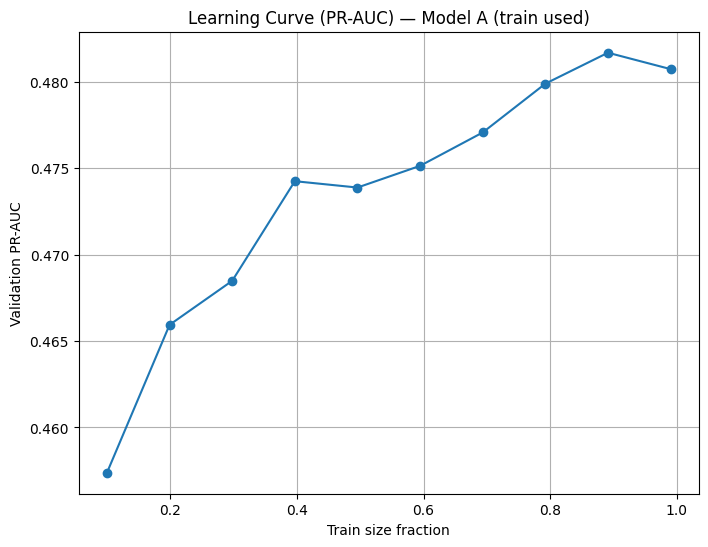

Train sizes: [0.1        0.19888889 0.29777778 0.39666667 0.49555556 0.59444444
 0.69333333 0.79222222 0.89111111 0.99      ]
PR-AUC: [np.float64(0.4573786994956245), np.float64(0.4659424228012007), np.float64(0.4684898876217048), np.float64(0.4742576252077234), np.float64(0.47388998716396247), np.float64(0.4751464005940258), np.float64(0.47707837614852927), np.float64(0.47990349832391066), np.float64(0.48169587271026965), np.float64(0.4807466060794394)]


In [ ]:
neg_count = (y_train_A == 0).sum()
pos_count = (y_train_A == 1).sum()
weight = neg_count / pos_count

model_params = dict(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=1000,
    early_stopping_rounds=80,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=weight,
    random_state=42
)

# learning curve
train_sizes = np.linspace(0.1, 0.99, 10)
scores = []

for size in train_sizes:
    X_part, _, y_part, _ = train_test_split(
        X_train_A, y_train_A,
        train_size=size,
        random_state=42,
        stratify=y_train_A
    )

    model = XGBClassifier(**model_params)

    model.fit(
        X_part, y_part,
        eval_set=[(X_val_A, y_val_A)],
        verbose=False
    )

    val_probs = model.predict_proba(X_val_A)[:, 1]
    pr_auc = average_precision_score(y_val_A, val_probs)
    scores.append(pr_auc)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, scores, marker="o")
plt.title("Learning Curve (PR-AUC) — Model A (train used)")
plt.xlabel("Train size fraction")
plt.ylabel("Validation PR-AUC")
plt.grid(True)
plt.show()

print("Train sizes:", train_sizes)
print("PR-AUC:", scores)


# Tuning model B

Model B gave us an optimistic outsanding result on the best iteration. Hovewer, it is suspected for instability, which will be confirmed in the following full train set cross validation

In [ ]:
X_full_B = pd.concat([X_train_B, X_val_B], axis=0).reset_index(drop=True)
y_full_B = np.concatenate([y_train_B, y_val_B], axis=0)


neg_count = (y_full_B == 0).sum()
pos_count = (y_full_B == 1).sum()
weight = neg_count / pos_count

params_B = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "n_estimators": 1000,
    "early_stopping_rounds": 40,
    "learning_rate": 0.05,
    "max_depth": 5,
    "min_child_weight": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": weight,
    "random_state": 42
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
best_iterations = []

for train_idx, val_idx in kf.split(X_full_B, y_full_B):
    X_tr, X_val = X_full_B.iloc[train_idx], X_full_B.iloc[val_idx]
    y_tr, y_val = y_full_B[train_idx], y_full_B[val_idx]

    model = XGBClassifier(**params_B)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_tr, y_tr), (X_val, y_val)],
        verbose=False
    )

    preds = model.predict_proba(X_val)[:, 1]
    pr_Buc = average_precision_score(y_val, preds)

    cv_scores.append(pr_Buc)
    best_iterations.append(model.best_iteration)

print("CV PR-AUC scores:", cv_scores)
print("Mean PR-AUC:", np.mean(cv_scores))
print("Best iterations per fold:", best_iterations)
print("Mean best iteration:", np.mean(best_iterations))


CV PR-AUC scores: [np.float64(0.05804433111129533), np.float64(0.05326705938769519), np.float64(0.0396447840720396), np.float64(0.0358193052461537), np.float64(0.02611829358859995)]
Mean PR-AUC: 0.04257875468115675
Best iterations per fold: [29, 23, 41, 7, 5]
Mean best iteration: 21.0


Since initial parametrs for model B gave instability, it's worth trying other model's parameters. I don't opt for another models, since XGBoost is considered to be the most effective out of tree models for table-like data, LightGBM would increase the instability. I tested it out of interest though and it gave poor results

In [ ]:
def xgb_gridsearch_cv(X, y, base_params, grid_params, n_splits=5):

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []

    for depth in grid_params["max_depth"]:
        for lam in grid_params["reg_lambda"]:
            for sub in grid_params["subsample"]:
                for col in grid_params["colsample_bytree"]:

                    cv_scores = []
                    best_iters = []


                    params = base_params.copy()
                    params.update({
                        "max_depth": depth,
                        "reg_lambda": lam,
                        "subsample": sub,
                        "colsample_bytree": col
                    })


                    for train_idx, val_idx in kf.split(X, y):
                        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
                        y_tr, y_val = y[train_idx], y[val_idx]

                        model = XGBClassifier(**params)

                        model.fit(
                            X_tr, y_tr,
                            eval_set=[(X_tr, y_tr), (X_val, y_val)],
                            verbose=False
                        )

                        preds = model.predict_proba(X_val)[:, 1]
                        pr_auc = average_precision_score(y_val, preds)

                        cv_scores.append(pr_auc)
                        best_iters.append(model.best_iteration)

                    results.append({
                        "mean_pr_auc": np.mean(cv_scores),
                        "std_pr_auc": np.std(cv_scores),
                        "mean_best_iter": np.mean(best_iters),
                        "max_depth": depth,
                        "reg_lambda": lam,
                        "subsample": sub,
                        "colsample_bytree": col,

                    })

    return pd.DataFrame(results).sort_values("mean_pr_auc", ascending=False)


In [ ]:
neg_count_B = (y_full_B == 0).sum()
pos_count_B = (y_full_B == 1).sum()
weight_B = neg_count_B / pos_count_B


base_params_B = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "n_estimators": 1000,
    "early_stopping_rounds": 40,
    "learning_rate": 0.05,
    "min_child_weight": 3,
    "scale_pos_weight": weight,
    "random_state": 42
}

grid_params_B = {
    "max_depth": [4, 5],
    "reg_lambda": [0.1, 0.2, 0.3],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.7, 0.8]
}

results_B = xgb_gridsearch_cv(X_full_B, y_full_B, base_params_B, grid_params_B)
results_B.head(10)


,mean_pr_auc,std_pr_auc,mean_best_iter,max_depth,reg_lambda,subsample,colsample_bytree
17,0.054387,0.020189,32.6,5,0.2,0.8,0.8
21,0.052705,0.023467,31.2,5,0.3,0.8,0.8
7,0.049256,0.025633,22.8,4,0.2,0.9,0.8
11,0.049233,0.025602,22.8,4,0.3,0.9,0.8
3,0.049232,0.025620,22.8,4,0.1,0.9,0.8
13,0.048750,0.019594,25.0,5,0.1,0.8,0.8
5,0.044863,0.017368,20.6,4,0.2,0.8,0.8
16,0.044231,0.015593,14.2,5,0.2,0.8,0.7
2,0.044110,0.020639,22.2,4,0.1,0.9,0.7
10,0.043606,0.020984,20.8,4,0.3,0.9,0.7


The first parameters combination clearly provided the best result

In [ ]:
final_params_B = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "n_estimators": 1000,
    "early_stopping_rounds": 40,
    "learning_rate": 0.05,


    "max_depth": 5,
    "min_child_weight": 3,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 0.2,

    "scale_pos_weight": weight_B,
    "random_state": 42
}



In [ ]:

model_B_final = XGBClassifier(**final_params_B)


model_B_final.fit(
    X_train_B, y_train_B,
    eval_set=[(X_train_B, y_train_B), (X_val_B, y_val_B)],
    verbose=True
)

print("Final best iteration:", model_B_final.best_iteration)

[0]	validation_0-aucpr:0.04051	validation_1-aucpr:0.01610
[1]	validation_0-aucpr:0.07058	validation_1-aucpr:0.02167
[2]	validation_0-aucpr:0.09697	validation_1-aucpr:0.02142
[3]	validation_0-aucpr:0.11363	validation_1-aucpr:0.02326
[4]	validation_0-aucpr:0.10840	validation_1-aucpr:0.02393
[5]	validation_0-aucpr:0.10607	validation_1-aucpr:0.02489
[6]	validation_0-aucpr:0.13638	validation_1-aucpr:0.02412
[7]	validation_0-aucpr:0.13247	validation_1-aucpr:0.02442
[8]	validation_0-aucpr:0.13760	validation_1-aucpr:0.02507
[9]	validation_0-aucpr:0.14167	validation_1-aucpr:0.02534
[10]	validation_0-aucpr:0.14071	validation_1-aucpr:0.02474
[11]	validation_0-aucpr:0.14132	validation_1-aucpr:0.02434
[12]	validation_0-aucpr:0.14193	validation_1-aucpr:0.02428
[13]	validation_0-aucpr:0.13691	validation_1-aucpr:0.02356
[14]	validation_0-aucpr:0.13219	validation_1-aucpr:0.02414
[15]	validation_0-aucpr:0.13026	validation_1-aucpr:0.02340
[16]	validation_0-aucpr:0.13051	validation_1-aucpr:0.02360
[17]	va

In [ ]:
n_estimators_B = 26

In [ ]:
y_pred_B = model_B_final.predict(X_val_B)
y_pred_B_proba = model_B_final.predict_proba(X_val_B)

cm_B = confusion_matrix(y_val_B, y_pred_B)

cm_B_df = pd.DataFrame(cm_B, index=["Actual At-Risk", "Actual Churn"], columns=["Predicted At-Risk", "Predicted Churn"])

cm_B_df


,Predicted At-Risk,Predicted Churn
Actual At-Risk,2636,451
Actual Churn,7,12


# Using predictions from model B

Churned clients differ from At-risk clients in their meaning, though the difference is not as crucial to the business as with Active VS Non-active clients.Churn logic can be implemented  as follows:

The model will give out a probability of client to be churned (the highest risk to business since client shows no interaction for a long time). Mixing client's probability to be churned and client's normed LTV the offer-score coefficient is produced. The more client is considered to be churned and the more valuable it is, the more business can spend to keep them. The formulas coefficients can be adjusted as one wants.

In [ ]:
probs = y_pred_B_proba[:, 1]
probs_churn = probs[y_val_B == 1]
probs_non_churn = probs[y_val_B == 0]
quantiles_churn = pd.Series(probs_churn).quantile([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
print("Quantiles for TRUE churn clients:")
print(quantiles_churn)

quantiles_non_churn = pd.Series(probs_non_churn).quantile([0.50, 0.75, 0.90, 0.95, 0.99])
print("Quantiles for NON-churn clients:")
print(quantiles_non_churn)


Quantiles for TRUE churn clients:
0.05    0.199308
0.10    0.208559
0.25    0.364400
0.50    0.594429
0.75    0.651424
0.90    0.742991
0.95    0.753345
0.99    0.768065
dtype: float64
Quantiles for NON-churn clients:
0.50    0.149115
0.75    0.310316
0.90    0.580100
0.95    0.694719
0.99    0.759558
dtype: float64


In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

probs = cross_val_predict(
    XGBClassifier(**final_params_B),
    X_full_B, y_full_B,
    cv=kf,
    method="predict_proba"
)[:, 1]

probs_churn = probs[y_full_B == 1]
quantiles_churn = pd.Series(probs_churn).quantile([0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

print("Quantiles for TRUE churn:")
print(quantiles_churn)

probs_non = probs[y_full_B == 0]
quantiles_non = pd.Series(probs_non).quantile([0.50,0.75,0.90,0.95,0.99])
print("Quantiles for NON-churn:")
print(quantiles_non)

Quantiles for TRUE churn:
0.05    0.167761
0.10    0.253544
0.25    0.380725
0.50    0.585775
0.75    0.697706
0.90    0.738223
0.95    0.756319
0.99    0.767555
dtype: float64
Quantiles for NON-churn:
0.50    0.152203
0.75    0.319775
0.90    0.578951
0.95    0.683853
0.99    0.757081
dtype: float64


In [ ]:
train_set_non_active = train_set[train_set['target'] != 'ACTIVE']

In [ ]:
train_set_non_active["ltv_score"] = (
    (train_set_non_active["succ_orders_count"]*train_set_non_active["avg_order_value"]) +
    (train_set_non_active["succ_orders_count_90d"]*train_set_non_active["avg_order_value_90d"])
)

quantiles = train_set_non_active["ltv_score"].quantile([0, 0.25, 0.5, 0.75, 0.95, 0.99])
print("LTV-score quantiles:")
print(quantiles)

q25 = quantiles.loc[0.25]
print("\n25th percentile (q25):", q25)


LTV-score quantiles:
0.00        0.000000
0.25     4015.770000
0.50    11525.749998
0.75    23070.520000
0.95    48422.503998
0.99    76176.967587
Name: ltv_score, dtype: float64

25th percentile (q25): 4015.77


/tmp/ipykernel_2590/3427106702.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_set_non_active["ltv_score"] = (


Normalization parameters for offer score formula

In [ ]:
ltv_min = train_set_non_active["ltv_score"].min()
ltv_q99 = train_set_non_active["ltv_score"].quantile(0.99)


norm_params = {
    "ltv_min": ltv_min,
    "ltv_q99": ltv_q99,
    'p_churn_cap': 0.77,
    "ltv_q25": q25,
    'birth_mode': birth_mode

}

joblib.dump(norm_params, "/content/drive/MyDrive/normalization_params.joblib")

['/content/drive/MyDrive/normalization_params.joblib']

In [ ]:
norm_params = joblib.load("normalization_params.joblib")

In [ ]:
ltv_min = norm_params["ltv_min"]
ltv_q99 = norm_params["ltv_q99"]
p_churn_cap = norm_params["p_churn_cap"]
ltv_q25 = norm_params["ltv_q25"]
birth_mode = norm_params["birth_mode"]

In [ ]:
def norm_ltv(ltv, ltv_min=ltv_min, ltv_max=ltv_q99):
  norm_ltv = (ltv - ltv_min) / (ltv_max - ltv_min)
  return norm_ltv

def p_churn_clip(p_churn, p_churn_cap=p_churn_cap):
    p_norm = p_churn / p_churn_cap
    return np.clip(p_norm, 0, 1)

# Offer-score formula

The offer score formula is a coeeficient which can be multiplied by any business discount (e.g. default discount is 25%, multiplying 25 by offer score we can adjust the size of sale depending on client's churn probability and LTV).

The offer score is 1 by default even if client has 0 normed LTV score, and 0 probability to be churned. The reason for that is because even if not churned, clients are still at risk group so business has to give them at least the smallest offer to not lose a client.

The more client is at risk and the more valuable it is, the higher the offer.

NOTE: churn probabilities will always be capped to 1, LTV normed is more flexible, meaning if there is a client with enormously high LTV, we might want to give them an extra offer. The lowest LTV score is 0 in our dataset, so the sign of LTV normed is always positive.  LTV is the only parameter in the formula that can make offer score even larger that 2, combined with churned probability >= 0.77 (the highest probability for actual churns in dataset).

The formula parameters such as churn and LTV coefficients can be adjusted as wanted, but i chose 0.6 for churn and 0.4 for LTV as basic parameters which look reasonable.

In [ ]:
def offer_score(p_churn_clip, ltv_norm, churn_coef=0.6, ltv_coef=0.4):
    offer_score = (churn_coef*p_churn_clip) + (ltv_coef*ltv_norm) + 1
    return offer_score

NOTE: learning curve for model B is considered to be ineffective due small amount of train data accompinied by less importance of model compared to model
a

# Final models' training

In [ ]:
n_estimators_A = 53
n_estimators_B = 26

In [ ]:
model_A_final, model_B_final = train_pipeline(X_train, y_train)

In [ ]:
joblib.dump(model_A_final, "/content/drive/MyDrive/model_A.joblib")
joblib.dump(model_B_final, "/content/drive/MyDrive/model_B.joblib")

['/content/drive/MyDrive/model_B.joblib']

I also saved models in json format to switch to VsCode for Shap, had troubles with joblib files

# Test evaluation

In [ ]:
X_test_shap = select_features(X_test)
X_test_shap = basic_cleaning(X_test_shap)
X_test_shap = feature_engineering(X_test_shap)
joblib.dump(X_test_shap, "/content/drive/MyDrive/X_test_shap.joblib")


['/content/drive/MyDrive/X_test_shap.joblib']

Due to the specifics of using Churned target, model's performance will be measured only on ACTIVE vs NON-ACTIVE predictions from model A.

**NORMAL CONFUSION MATRIX:**

Clients are considered NON-ACTIVE is their probability is greater or equal to 0.35

**CONFUSION MATRIX WITH ADDITIONAL LTV FILTRATION:**


Business logic filtration will be applied to the first confusion matrix, meaning a client will be considered ACTIVE if he is eaither ACTIVE or LOW-RISK LOW-VALUE. This will show how applying such business logic and ignoring LOW-RISK LOW-VALUE clients will affect Precision and Recall and can help with choosing the right business strategy



In [ ]:
out = prediction_pipeline(X_test, model_A_final, model_B_final)

In [ ]:
out.head(5)

,customer_id,segment,offer_score,churn_prob,active_prob
24845,27327,ACTIVE,0.000000,0.000000,0.925730
71005,78124,NON-ACTIVE,1.319024,0.133896,0.591420
59953,65964,NON-ACTIVE,1.392505,0.376951,0.324084
48265,53116,NON-ACTIVE,1.143891,0.132757,0.337541
28223,31038,NON-ACTIVE,1.106689,0.136918,0.303772


Normal confusion matrix

It is clear that model's performance is not really good. However, the big amount of NON-ACTIVE clients is found. It leaves us with many false positives, though the model is not classyfying everyone as NON-ACTIVE, finding risk clients well at the same time. Keeping that in mind, we can either try to improve features or data quality and its amount



In [ ]:
def evaluate_model_A_treshold(test_df, p_A, threshold=0.35):
    true = (test_df["target"] != "ACTIVE").astype(int)
    pred = (p_A >= threshold).astype(int)
    cm = confusion_matrix(true, pred, labels=[0, 1])
    return cm


In [ ]:
cm_1 = evaluate_model_A_treshold(y_test, 1 - out["active_prob"], threshold=0.35)
cm_1_df = pd.DataFrame(cm_1, index=["Actual Active", "Actual Non-active"], columns=["Predicted Active", "Predicted Non-active"])
cm_1_df

,Predicted Active,Predicted Non-active
Actual Active,4341,8667
Actual Non-active,210,4966


Confusion matrix with additional LTV filtration

For comparison , the following evaluation will be made considering LOW-RISK AND LOW-VALUE clients as ACTIVE as discussed before. Some actualy NON-ACTIVE clients are dismissed, though there are less False Positives. The final decision whether or not to choose this strategy is left to business, though it's definitely worth trying to try improving overall model's performance by altering data as mentioned before

In [ ]:
def evaluate_model_A(test_df, out_df):
    seg = out_df["segment"].copy()
    seg = seg.replace({"LOW-RISK AND LOW-VALUE": "ACTIVE"})

    true = test_df["target"].replace({
        "ACTIVE": "ACTIVE",
        "AT-RISK": "NON-ACTIVE",
        "CHURNED": "NON-ACTIVE"
    })

    cm = confusion_matrix(true, seg, labels=["ACTIVE", "NON-ACTIVE"])
    return cm


In [ ]:
cm = evaluate_model_A(y_test, out)
cm_df = pd.DataFrame(cm, index=["Actual Active", "Actual Non-active"], columns=["Predicted Active", "Predicted Non-active"])
cm_df

,Predicted Active,Predicted Non-active
Actual Active,4601,8407
Actual Non-active,291,4885


**Conclusion:**

The decision is left to business which balance they prefere. Overall model performance unfortunately is kind of poor, though as said earlier, this may be the result of synthetic data, ambigous boundaries between different classes or insufficient feature quality.

# SHAP for models

**Model A**:

Non-active(1)
Active(0)

Train set SHAP

In [ ]:
import xgboost as xgb
model_A = xgb.XGBClassifier()
model_A.load_model("model_A.json")

model_B = xgb.XGBClassifier()
model_B.load_model("model_B.json")

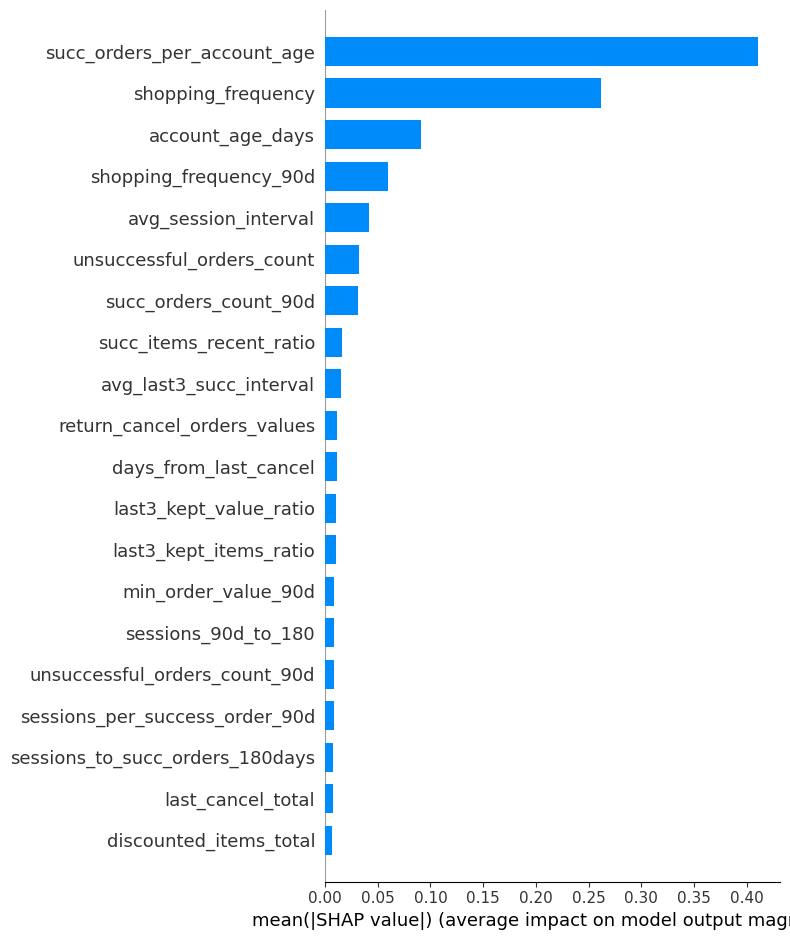

In [ ]:
explainer_A = shap.TreeExplainer(model_A)
shap_values_A = explainer_A.shap_values(X_full_A)

shap.summary_plot(shap_values_A, X_full_A, plot_type="bar", show=True)



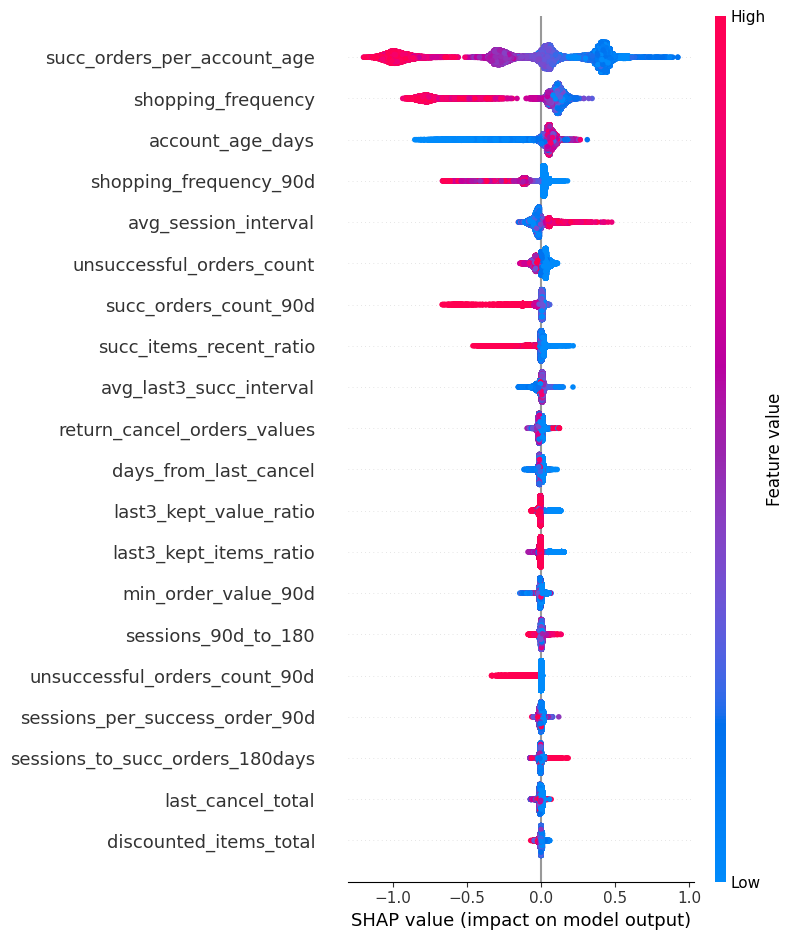

In [ ]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_A, X_full_A, plot_type="dot")

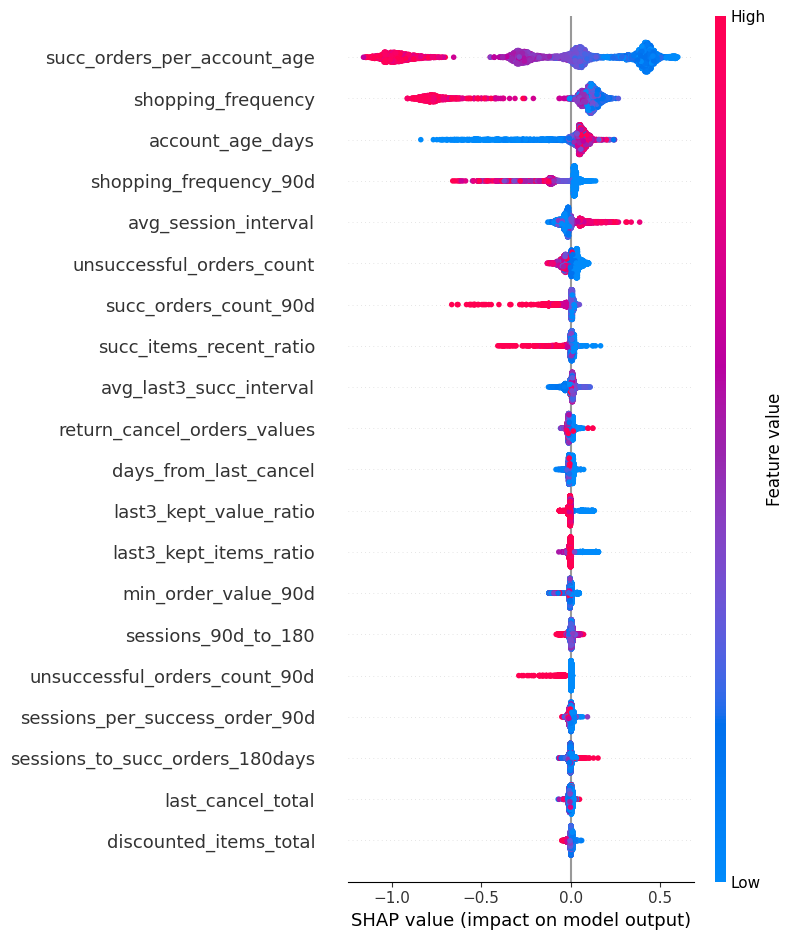

In [ ]:
X_test_shap_A = prepare_A_inference(X_test_shap)
X_shap = X_test_shap_A.sample(5000, random_state=42)


explainer = shap.TreeExplainer(
    model_A,
    feature_perturbation="tree_path_dependent",
    model_output="raw"
)

shap_values = explainer.shap_values(
    X_shap,
    check_additivity=False
)

shap.summary_plot(shap_values, X_shap, plot_type="dot")

plt.savefig("shap_summary_A.png", dpi=300, bbox_inches='tight')


plt.close()


**Model B:**

Churned(1) At-Risk(0)

Train set SHAP

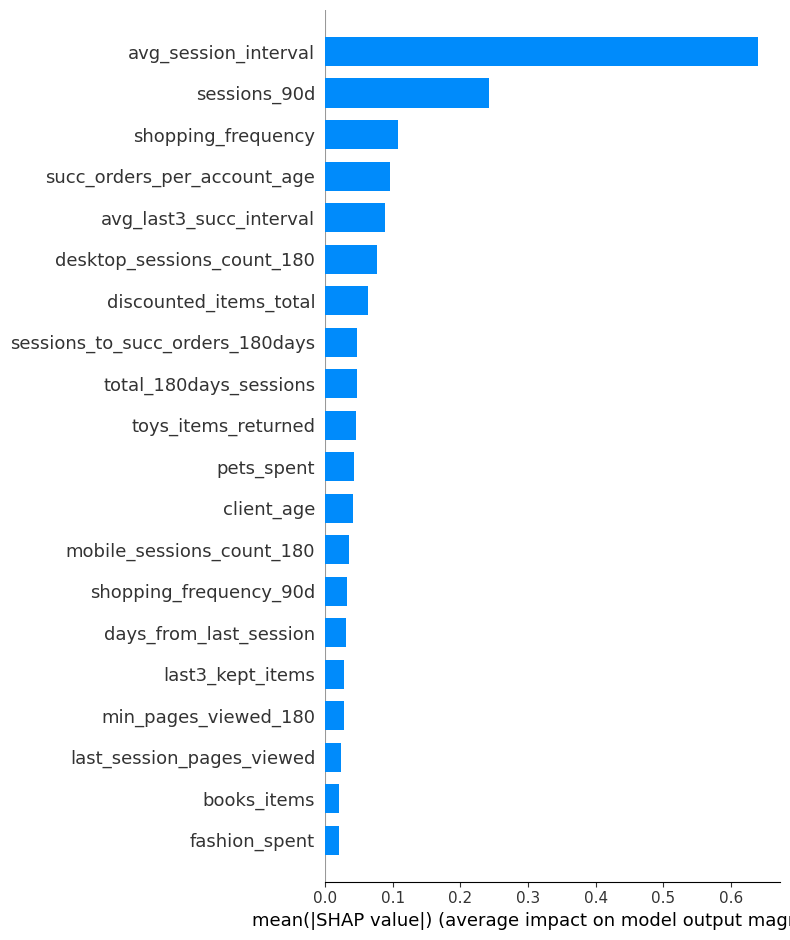

In [ ]:
X_full_B = X_full_B.drop(columns=["succ_orders_count_90d", "avg_order_value_90d"])
explainer_B = shap.TreeExplainer(model_B)
shap_values_B = explainer_B.shap_values(X_full_B)

shap.summary_plot(shap_values_B, X_full_B, plot_type="bar", show=True)

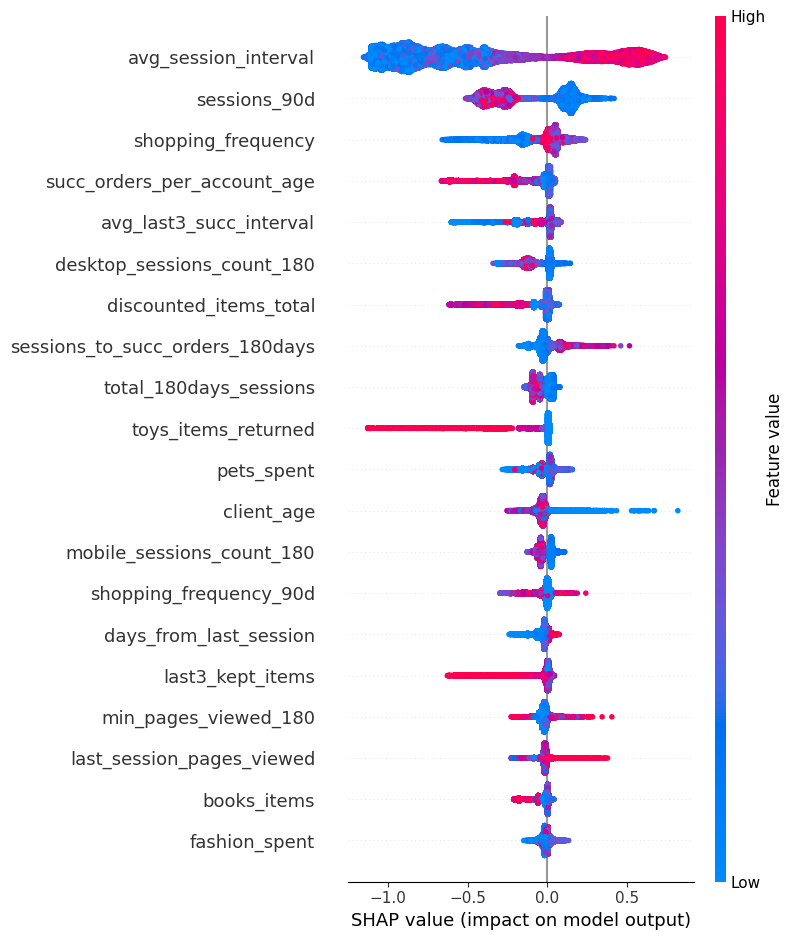

In [ ]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_B, X_full_B, plot_type="dot")

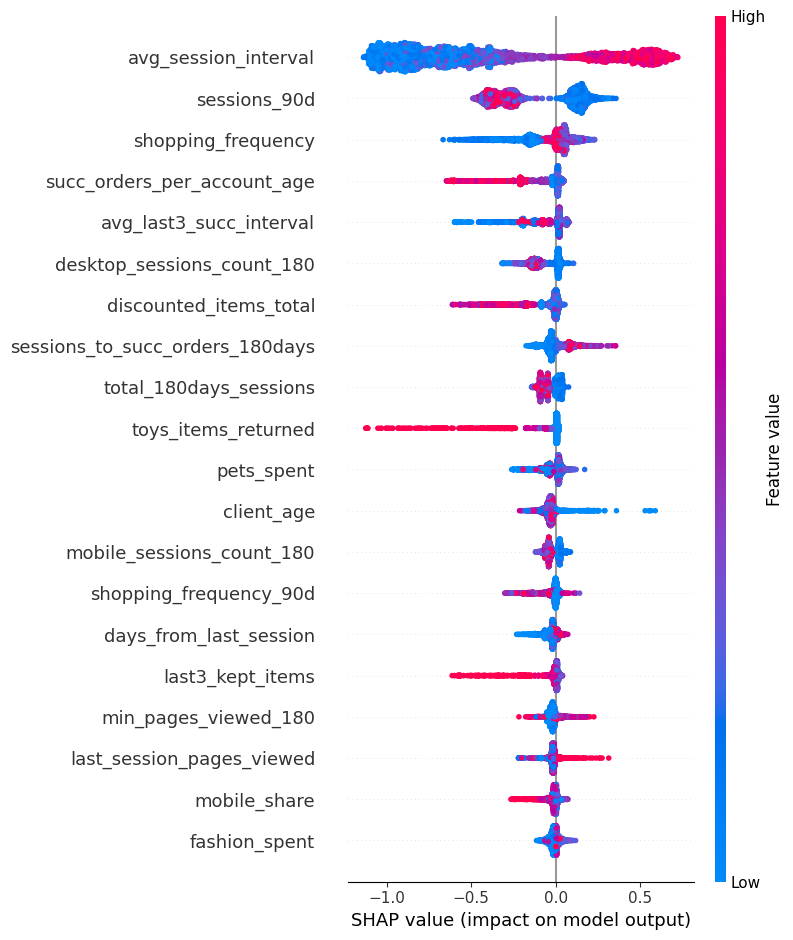

In [ ]:
X_test_shap_B = prepare_B_inference(X_test_shap)
X_test_shap_B = X_test_shap_B.drop(columns= ['succ_orders_count_90d', 'avg_order_value_90d'])
X_shap = X_test_shap_B.sample(5000, random_state=42)


explainer = shap.TreeExplainer(
    model_B,
    feature_perturbation="tree_path_dependent",
    model_output="raw"
)

shap_values = explainer.shap_values(
    X_shap,
    check_additivity=False
)

shap.summary_plot(shap_values, X_shap, plot_type="dot")

plt.savefig("shap_summary_B.png", dpi=300, bbox_inches='tight')


plt.close()


# Feature contract

In [ ]:
FEATURES = [
    "customer_id",
    "account_age_days",
    "birth_date",
    "shopping_frequency",
    "unsuccessful_orders_count",
    "succ_orders_count",
    "avg_order_value",
    "min_order_value",
    "avg_items_per_order",
    "total_succ_items_per_customer",
    "return_cancel_orders_values",
    "return_cancel_orders_items",
    "shopping_frequency_90d",
    "unsuccessful_orders_count_90d",
    "succ_orders_count_90d",
    "avg_order_value_90d",
    "min_order_value_90d",
    "avg_items_per_order_90d",
    "total_succ_items_per_customer_90d",
    "return_cancel_orders_values_90d",
    "return_cancel_orders_items_90d",
    "last_suc_order_interval",
    "last_succ_kept_order_total",
    "last_succ_kept_order_items",
    "last_succ_order_items",
    "last_succ_order_total",
    "days_from_last_return",
    "last_return_total",
    "last_returned_items",
    "days_from_last_cancel",
    "last_cancel_items",
    "last_cancel_total",
    "avg_last3_succ_interval",
    "last3_succ_orders_kept_items_total",
    "last3_succ_orders_kept_total",
    "last3_succ_orders_total",
    "last3_succ_orders_items",
    "last3_return_cancel_order_total",
    "last3_kept_total",
    "last3_cancels_returns_items",
    "last3_kept_items",
    "automotive_items",
    "automotive_spent",
    "beauty_items",
    "beauty_spent",
    "books_items",
    "books_spent",
    "electronics_items",
    "electronics_spent",
    "fashion_items",
    "fashion_spent",
    "food_items",
    "food_spent",
    "home_items",
    "home_spent",
    "pets_items",
    "pets_spent",
    "sports_items",
    "sports_spent",
    "toys_items",
    "toys_spent",
    "automotive_items_returned",
    "automotive_returned_total",
    "beauty_items_returned",
    "beauty_returned_total",
    "books_items_returned",
    "books_returned_total",
    "electronics_items_returned",
    "electronics_returned_total",
    "fashion_items_returned",
    "fashion_returned_total",
    "food_items_returned",
    "food_returned_total",
    "home_items_returned",
    "home_returned_total",
    "pets_items_returned",
    "pets_returned_total",
    "sports_items_returned",
    "sports_returned_total",
    "toys_items_returned",
    "toys_returned_total",
    "discounted_items_total",
    "total_180days_sessions",
    "avg_pages_viewed_180",
    "min_pages_viewed_180",
    "mobile_sessions_count_180",
    "desktop_sessions_count_180",
    "sessions_to_succ_orders_180days",
    "sessions_90d",
    "avg_pages_90d",
    "days_from_last_session",
    "last_session_pages_viewed",
    "avg_session_interval"
]


In [ ]:
drop_A = [
        "automotive_items_returned",
        "beauty_items_returned",
        "books_items_returned",
        "electronics_items_returned",
        "fashion_items_returned",
        "food_items_returned",
        "home_items_returned",
        "pets_items_returned",
        "sports_items_returned",
        "toys_items_returned"
    ]

drop_B = [
    "beauty_items",
    "automotive_spent",
    "last3_kept_total",
    "last3_cancels_returns_items",
    "last3_succ_orders_kept_total",
    "last3_return_cancel_order_total",
    "last_cancel_total",
    "last_cancel_items",
    "last_succ_order_items",
    "last_succ_kept_order_total",
    "last_succ_order_total",
    "days_from_last_return",
    "last_return_total",
    "last_returned_items",
    # "succ_orders_count_90d",  # KEEP
    "avg_items_per_order_90d",
    "min_order_value_90d",
    "total_succ_items_per_customer_90d",
    # "avg_order_value_90d",    # KEEP
    "return_cancel_orders_items",
    "account_age_days",
    "unsuccessful_orders_count",
    "food_spent",
    "pets_items",
    "home_spent",
    "home_items",
    "food_items",
    "fashion_items",
    "books_spent",
    "sports_items_returned",
    "pets_returned_total",
    "pets_items_returned",
    "home_returned_total",
    "home_items_returned",
    "food_returned_total",
    "food_items_returned",
    "fashion_returned_total",
    "fashion_items_returned",
    "electronics_returned_total",
    "electronics_items_returned",
    "books_returned_total",
    "beauty_returned_total",
    "beauty_items_returned",
    "toys_spent",
    "automotive_items_returned",
    "electronics_items",
    "electronics_spent",
    "toys_items",
    "sports_spent",
    "toys_returned_total",
    "sports_returned_total",
    "avg_pages_viewed_180",
    "last_session_pages_to_avg90",
    "last3_kept_value_ratio",
    "last3_kept_items_ratio",
    "last_kept_items_ratio",
    "last3_succ_kept_value_to_avg_ratio",
    "avg_order_value_recent_ratio",
    "last_succ_kept_value_to_avg_ratio",
    "sessions_per_success_order_90d",
    "min_order_value_delta"
  ]

# Pipeline functions

In [ ]:
def load_data(path):
    df = pd.read_parquet(path)
    return df

def select_features(df, feature_list=FEATURES):
    missing = [f for f in feature_list if f not in df.columns]
    if missing:
        raise ValueError(f"Missing required features: {missing}")
    return df[feature_list].copy()


def basic_cleaning(df, birth_mode=birth_mode):
    df = df.copy()
    if 'customer_id' in df.columns:
      df = df.drop(columns=['customer_id'])
    df['birth_date'] = df['birth_date'].fillna(birth_mode)
    df['birth_date'] = pd.to_datetime(df['birth_date'])
    reference_date = pd.to_datetime('2026-01-01')
    df['client_age'] = ((reference_date - df['birth_date']).dt.days // 365).astype(int)
    df = df.drop(columns=['birth_date'])
    return df

def feature_engineering(df):
    df = df.copy()

    def safe_div(n, d):
        return (n / d).replace([np.inf, -np.inf], 0).fillna(0)

    df["last_session_pages_to_avg90"] = safe_div(df["last_session_pages_viewed"], df["avg_pages_90d"])
    df["sessions_90d_to_180"] = safe_div(df["sessions_90d"], df["total_180days_sessions"])
    df["avg_pages_90d_to_180"] = safe_div(df["avg_pages_90d"], df["avg_pages_viewed_180"])
    df["mobile_share"] = safe_div(df["mobile_sessions_count_180"], df["desktop_sessions_count_180"] + df["mobile_sessions_count_180"])
    df["last_kept_items_ratio"] = safe_div(df["last_succ_kept_order_items"], df["last_succ_order_items"])
    df["last_kept_value_ratio"] = safe_div(df["last_succ_kept_order_total"], df["last_succ_order_total"])
    df["last3_kept_items_ratio"] = safe_div(df["last3_kept_items"], df["last3_kept_items"] + df["last3_cancels_returns_items"])
    df["last3_kept_value_ratio"] = safe_div(df["last3_kept_total"], df["last3_kept_total"] + df["last3_return_cancel_order_total"])
    df["last3_succ_kept_value_to_avg_ratio"] = safe_div(df["last3_succ_orders_kept_total"], 3 * df["avg_order_value"])
    df["last_succ_kept_value_to_avg_ratio"] = safe_div(df["last_succ_kept_order_total"], df["avg_order_value"])
    df["avg_items_per_order_recent_ratio"] = safe_div(df["avg_items_per_order_90d"], df["avg_items_per_order"])
    df["avg_order_value_recent_ratio"] = safe_div(df["avg_order_value_90d"], df["avg_order_value"])
    df["succ_items_recent_ratio"] = safe_div(df["total_succ_items_per_customer_90d"], df["total_succ_items_per_customer"])
    df["sessions_per_success_order_90d"] = safe_div(df["sessions_90d"], df["succ_orders_count_90d"])
    df["min_order_value_delta"] = df["min_order_value_90d"] - df["min_order_value"]
    df["succ_orders_per_account_age"] = safe_div(df["succ_orders_count"], df["account_age_days"])

    return df


def merge_by_customer_id(features_df, target_df):
    if "customer_id" not in features_df.columns:
        raise ValueError("customer_id missing in features_df")
    if "customer_id" not in target_df.columns:
        raise ValueError("customer_id missing in target_df")

    merged = features_df.merge(target_df, on="customer_id", how="inner")
    merged = merged.drop(columns=["customer_id"])
    return merged


def split_X_y(df, target_col="target"):
    if target_col not in df.columns:
        raise ValueError(f"{target_col} missing in dataframe")

    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y



In [ ]:
def prepare_A(df, drop_feat=drop_A):
    df_A = df.copy()
    df_A["is_not_active"] = df_A["target"].apply(lambda x: 1 if x != "ACTIVE" else 0)

    df_A = df_A.drop(columns=drop_feat, errors="ignore")

    X = df_A.drop(columns=["target", "is_not_active"])
    y = df_A["is_not_active"]
    return X, y


def prepare_B(df, drop_feat=drop_B):
    df_B = df[df["target"] != "ACTIVE"].copy()
    df_B["is_churn"] = df_B["target"].apply(lambda x: 1 if x == "CHURNED" else 0)


    df_B = df_B.drop(columns=drop_feat, errors="ignore")

    X = df_B.drop(columns=["target", "is_churn"])
    y = df_B["is_churn"]
    return X, y


In [ ]:
def train_model_A(X, y, n_estimators_A=n_estimators_A):
    from xgboost import XGBClassifier

    neg = (y == 0).sum()
    pos = (y == 1).sum()
    weight = neg / pos

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=n_estimators_A,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=weight,
        random_state=42
    )

    model.fit(X, y)
    return model

def train_model_B(X, y, n_estimators_B=n_estimators_B):
    from xgboost import XGBClassifier

    if "succ_orders_count_90d" in X.columns and "avg_order_value_90d" in X.columns:
      X = X.drop(columns =["succ_orders_count_90d", "avg_order_value_90d"])

    neg = (y == 0).sum()
    pos = (y == 1).sum()
    weight_B = neg / pos

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=n_estimators_B,
        learning_rate=0.05,

        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=0.2,

        scale_pos_weight=weight_B,
        random_state=42
    )

    model.fit(X, y)
    return model



In [ ]:
def prepare_A_inference(df, drop_feat=drop_A):

    df_A = df.drop(columns=drop_feat, errors="ignore")

    return df_A


def prepare_B_inference(df, drop_feat=drop_B):

    df_B = df.drop(columns=drop_feat, errors="ignore")

    return df_B


In [ ]:
def predict_A(df, model_A):
    df_A = prepare_A_inference(df)
    p_not_active = model_A.predict_proba(df_A)[:, 1]
    return p_not_active

def predict_B(df, model_B):
    df_B = prepare_B_inference(df)
    X = df_B.drop(columns =["succ_orders_count_90d", "avg_order_value_90d"])
    p_churn = model_B.predict_proba(X)[:, 1]
    return p_churn


In [ ]:
def train_pipeline(X, y):
    X_sel = select_features(X, FEATURES)
    df_merged = merge_by_customer_id(X_sel, y)
    df_clean = basic_cleaning(df_merged)
    df_fin = feature_engineering(df_clean)


    X_A, y_A = prepare_A(df_fin)
    X_B, y_B = prepare_B(df_fin)

    model_A = train_model_A(X_A, y_A, n_estimators_A)
    model_B = train_model_B(X_B, y_B, n_estimators_B)

    return model_A, model_B

In [ ]:
def prediction_pipeline(df, model_A, model_B, FEATURES=FEATURES, ltv_q25=ltv_q25, birth_mode=birth_mode):
    df_sel = select_features(df, FEATURES)
    ids = df['customer_id']
    df_clean = basic_cleaning(df_sel, birth_mode)
    df_fin = feature_engineering(df_clean)

    df_fin["ltv_score"] = (
        (df_fin["succ_orders_count"] * df_fin["avg_order_value"]) +
        (df_fin["succ_orders_count_90d"] * df_fin["avg_order_value_90d"])
    )
    df_fin["ltv_norm"] = df_fin["ltv_score"].apply(norm_ltv)

    service_cols = ["ltv_norm", "ltv_score"]

    out = pd.DataFrame(ids)
    out["segment"] = "ACTIVE"
    out["offer_score"] = 0.0
    out["churn_prob"] = 0.0


    p_A_all = predict_A(df_fin.drop(columns=service_cols), model_A)

    out["active_prob"] = 1-p_A_all

    df_fin["p_A"] = p_A_all


    mask_low_risk = (df_fin["p_A"] >= 0.35) & (df_fin["p_A"] < 0.55) & (df_fin["ltv_score"] < ltv_q25)
    mask_non_active = ((df_fin["p_A"] >= 0.35) & ~mask_low_risk)|(df_fin["p_A"] >= 0.6)


    mask_B_input = mask_non_active | mask_low_risk
    df_B_input = df_fin.loc[mask_B_input]


    p_B = predict_B(df_B_input.drop(columns=service_cols + ['p_A']), model_B)
    p_B_clip = p_churn_clip(p_B)

    offer_score_vals = [
        offer_score(pb, ltv)
        for pb, ltv in zip(p_B_clip, df_B_input["ltv_norm"])
        ]

    out.loc[mask_low_risk.values, "segment"] = "LOW-RISK AND LOW-VALUE"
    out.loc[mask_non_active.values, "segment"] = "NON-ACTIVE"
    out.loc[mask_B_input.values, "offer_score"] = offer_score_vals
    out.loc[mask_B_input.values, "churn_prob"] = p_B


    return out